# TinyProto FP train 50client

**TinyProto-FP** — Lee & Choi, *Communication-Efficient Heterogeneous Federated Learning with
Sparse Prototypes in Resource-Constrained Environments* (AAAI-26 submission 02846), §4.1–4.3,
Algorithm 1. Classifier at every client: **DAGSNet** (Khan et al. 2025, *Sci. Rep.*
`10.1038/s41598-025-94445-9` §4.10, Eq. 38–48), 395,024 parameters, 66 raw features in,
16 logits out.

Each client trains one local epoch on its own shard, computes class-mean activations of the
penultimate layer (Eq. 3), sparsifies them with a fixed per-class binary mask (CPS, Eq. 7–8),
scales them by its class counts (APS, Eq. 10) and uploads only the `s` non-zero entries. The
server averages those over the clients holding each class and sends them back; the next round
adds `λ·R_i` (Eq. 5, 11) to the cross-entropy. **No model weights are ever exchanged** — every
client keeps its own model for the whole run, which is why all 10 metrics are measured per
client on the full fixed test set every round.

## Paper vs. this notebook

| item | paper | here | why |
|---|---|---|---|
| dataset | CIFAR-10/100, GTSRB-43, Flowers-102, Tiny-ImageNet-200, AG News | VeReMi NextGen, 16 classes, 43,045,415 train / 10,761,343 test | project target |
| client architectures | 4 different lightweight CNNs across clients | **DAGSNet at every client** | user requirement — this build does **not** test the paper's model-heterogeneity claim |
| feature extractor | separate extraction stage | **dropped**, 66 raw z-scored features | user requirement |
| feature dim `d` | 500 | **256** (DAGSNet `head[3]`) | fixed by the architecture |
| CPS dim `s` | 50 (= 90% compression at d=500) | **50** (= 80.5% at d=256) | keeps the paper's value; its two statements conflict at d=256 |
| clients / rounds / batch | 20 / 300 / 32 | **50 / 50 / 512** | user specification |
| Dirichlet α | 0.1 | **0.5** | the partition that exists |
| optimizer | not named (reference code uses SGD), lr 0.01 | **AdamW, lr 1e-3, wd 1e-4**, no scheduler | user decision; the configuration proven on this model and data |
| ρ(·,·) | "Euclidean distance" | masked MSE over the `s` active dims, per sample | reduces to FedProto's `nn.MSELoss` when `s = d` |
| prototype timing | Eq. (3) is written for one θ_i | one inference pass **after** the local epoch, in `eval()` | a local epoch here is up to 11,506 steps, not ~59 |
| μ | 5 published values; method "in the appendix" — **the PDF has no appendix** | **grid search on a train-side validation split** | user decision; this build's realization, not the authors' method |
| seeds | 3, averaged | **1 (seed 42)** | GPU budget — **no replication** |

Full decision table with every gap named: `docs/rebuild.md`.


In [1]:
import os, sys, json, time, math, shutil, platform, subprocess
import numpy as np, torch

SESSION_STARTED_AT = time.time()
os.environ.setdefault("TORCHINDUCTOR_COMPILE_THREADS", "1")
print("python", platform.python_version(), "| torch", torch.__version__, "| cuda", torch.version.cuda)
try:
    print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True, check=True).stdout)
except (OSError, subprocess.CalledProcessError) as e:
    print("nvidia-smi probe:", type(e).__name__)
n = torch.cuda.device_count()
names, caps = [], []
for i in range(n):
    p = torch.cuda.get_device_properties(i)
    names.append(p.name); caps.append((p.major, p.minor))
    print(f"  cuda:{i} {p.name} {p.total_memory/2**30:.1f} GB sm_{p.major}{p.minor} SMs {p.multi_processor_count}")
print("cpu:", os.cpu_count(), "| RAM GB:",
      round(os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 2**30, 1),
      "| free on /kaggle/working GB:", round(shutil.disk_usage("/kaggle/working").free / 2**30, 1))
print("free on /kaggle/temp GB:", round(shutil.disk_usage("/kaggle/temp").free / 2**30, 1)
      if os.path.isdir("/kaggle/temp") else "n/a")

# An invalid machine_shape is silently coerced to a single P100 -- no error, no warning. This
# assert is the cheap failure; a run that proceeds on an unconfirmed accelerator is not.
assert n == 2, f"expected 2 GPUs, got {n}. Set machine_shape=NvidiaTeslaT4."
assert all("T4" in x for x in names), f"expected Tesla T4, got {names}"
assert all(c == (7, 5) for c in caps), f"expected sm_75, got {caps}"
print("\nOK: 2 x Tesla T4 (sm_75) confirmed before any training.")


python 3.12.13 | torch 2.10.0+cu128 | cuda 12.8
GPU 0: Tesla T4 (UUID: GPU-126e7bb0-ff79-852a-e4b8-8159d343d322)
GPU 1: Tesla T4 (UUID: GPU-65907f2b-bb69-44a6-713e-d52d40c3213c)

  cuda:0 Tesla T4 14.6 GB sm_75 SMs 40
  cuda:1 Tesla T4 14.6 GB sm_75 SMs 40
cpu: 4 | RAM GB: 31.3 | free on /kaggle/working GB: 19.5
free on /kaggle/temp GB: n/a

OK: 2 x Tesla T4 (sm_75) confirmed before any training.


## The knob cell

Everything retunable lives here.

In [2]:
CFG = {
    "run_name": "tinyproto_fp_50client",
    "scenario": "50client",
    "n_clients": 50,

    # ---- the paper's protocol -----------------------------------------------
    "rounds": 50,            # communication rounds T
    "local_epochs": 1,             # §5.1
    "lam": 1.0,                    # λ in Eq. (5); §5.1 "we set λ = 1 following FedProto"
    "cps_s": 50,                   # CPS dimension s; §5.1 default
    "mask_seed": 42,

    # ---- APS scaling constant μ (Eq. 11) ------------------------------------
    # These two are PLACEHOLDERS. require_mu_selection below makes the config cell read the
    # winner out of the attached mu_sweep.json and overwrite them, but only if that document
    # matches this scenario and this data fingerprint. Do not hand-copy a number here: a
    # hand-copied mu is not checked against anything.
    "mu_kind": "inv_mean_nij",
    "mu_value": 1.0,
    "require_mu_selection": True,
    "mu_selection_path": None,  # optional exact path to the scenario-specific mu_sweep.json

    # ---- this build's choices ----------------------------------------------
    "batch": 512,              # per client; user specification
    "eval_batch": 8192,
    "lr": 1e-3, "weight_decay": 1e-4, "betas": [0.9, 0.999], "eps": 1e-8,
    "clip": 1.0, "amp": True, "compile": True,
    "eval_group": 1,               # MEASURED on 2 x T4 (calibration 2026-09-08): the vmapped
                                   # path is SLOWER than folded-sequential (0.50/0.64/0.62x at
                                   # G=2/4/8) and differs numerically (0.028% of confusion
                                   # entries). Both reasons independently rule it out. Do not
                                   # raise this without re-measuring.
    "seed": 42,
    "num_classes": 16, "n_features": 66, "feature_dim": 256,

    # ---- session management -------------------------------------------------
    "max_hours": 11.0,      # stop before Kaggle's 12 h cap, leaving commit time
    "expected_round_s": 1300.0,   # calibration-derived; only used to gate the FIRST
                                   # round of a session, before this run has timed one itself.
                                   # 20-client is measured; 50/100 are projections from it.
    "rounds_this_session": None,   # set an int to force an earlier session boundary
    "require_resume": False,  # True on a push whose ONLY purpose is to continue
    "import_roots": ["/kaggle/input"],
    "save_preds_rounds": [50],
}
for k, v in CFG.items():
    print(f"  {k:22s} {v}")


  run_name               tinyproto_fp_50client
  scenario               50client
  n_clients              50
  rounds                 50
  local_epochs           1
  lam                    1.0
  cps_s                  50
  mask_seed              42
  mu_kind                inv_mean_nij
  mu_value               1.0
  require_mu_selection   True
  mu_selection_path      None
  batch                  512
  eval_batch             8192
  lr                     0.001
  weight_decay           0.0001
  betas                  [0.9, 0.999]
  eps                    1e-08
  clip                   1.0
  amp                    True
  compile                True
  eval_group             1
  seed                   42
  num_classes            16
  n_features             66
  feature_dim            256
  max_hours              11.0
  expected_round_s       1300.0
  rounds_this_session    None
  require_resume         False
  import_roots           ['/kaggle/input']
  save_preds_rounds      [50]


## Algorithm source

`%%writefile` keeps the code visible here **and** importable by the spawned worker processes — functions defined in notebook cells are not. These files are byte-identical to `src/` in the repository, which is where they are tested.

In [3]:
import pathlib, sys
PKG = pathlib.Path("/kaggle/working/proj"); PKG.mkdir(parents=True, exist_ok=True)
(PKG / "__init__.py").write_text("")
sys.path.insert(0, "/kaggle/working")
print("package dir:", PKG)


package dir: /kaggle/working/proj


In [4]:
%%writefile /kaggle/working/proj/model.py
"""DAGSNet — Khan et al. 2025 §4.10, Eq. (38)-(48). 395,024 learnable parameters.

Copied verbatim from `knowledge/architecture.md` §6 so that a state_dict written by either
file loads in the other with `strict=True`. The only addition is the feature/classifier split
that prototype-based FL needs: `forward_both` returns the penultimate activation alongside the
logits, without changing any parameter name or shape.

In:  (B, 66) z-scored features.   Out: (B, 16) logits (NOT softmaxed) and (B, 256) features.
"""
from __future__ import annotations

import torch
import torch.nn as nn


def cbr(i: int, o: int, k: int) -> nn.Sequential:
    """Conv -> BatchNorm -> ReLU. bias=False because the BatchNorm that follows has its own shift."""
    return nn.Sequential(nn.Conv1d(i, o, k, padding=k // 2, bias=False),
                         nn.BatchNorm1d(o), nn.ReLU(inplace=True))


class DenseNet1d(nn.Module):
    """Eq. (38)-(39): every layer sees the concatenation of all previous feature maps."""

    def __init__(self, cin: int, growth: int, layers: int):
        super().__init__()
        self.blocks = nn.ModuleList([cbr(cin + i * growth, growth, 3) for i in range(layers)])
        self.out_ch = cin + layers * growth

    def forward(self, x):
        for b in self.blocks:
            x = torch.cat([x, b(x)], dim=1)                     # Eq. (38)
        return x                                                # Eq. (39)


class Inception1d(nn.Module):
    """Eq. (40): four parallel branches 1x1 / 3x3 / 5x5 / pool, concatenated."""

    def __init__(self, cin: int, c: int):
        super().__init__()
        self.b1 = cbr(cin, c, 1)
        self.b3 = nn.Sequential(cbr(cin, c, 1), cbr(c, c, 3))
        self.b5 = nn.Sequential(cbr(cin, c, 1), cbr(c, c, 5))
        self.bp = nn.Sequential(nn.MaxPool1d(3, 1, 1), cbr(cin, c, 1))
        self.out_ch = 4 * c

    def forward(self, x):
        return torch.cat([self.b1(x), self.b3(x), self.b5(x), self.bp(x)], dim=1)


class GoogleNet1d(nn.Module):
    """Eq. (40)-(41): stacked inception modules."""

    def __init__(self, cin: int, modules_n: int, c: int = 32):
        super().__init__()
        mods, ch = [], cin
        for _ in range(modules_n):
            m = Inception1d(ch, c)
            mods.append(m)
            ch = m.out_ch
        self.net = nn.Sequential(*mods)
        self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class AlexNet1d(nn.Module):
    """Eq. (42)-(44). ceil_mode=True: the position axis is only 11 long, pooling must not
    collapse it to 0."""

    def __init__(self, cin: int, ch: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            cbr(cin, ch, 3), nn.MaxPool1d(2, ceil_mode=True),
            cbr(ch, ch, 3), nn.MaxPool1d(2, ceil_mode=True),
            cbr(ch, ch, 3))
        self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class Fire1d(nn.Module):
    """Eq. (45)-(46): a 1x1 squeeze feeding two expand branches, 1x1 and 3x3."""

    def __init__(self, cin: int, sq: int, ex: int):
        super().__init__()
        self.squeeze = cbr(cin, sq, 1)                          # Eq. (46)
        self.e1 = cbr(sq, ex, 1)
        self.e3 = cbr(sq, ex, 3)
        self.out_ch = 2 * ex

    def forward(self, x):
        s = self.squeeze(x)
        return torch.cat([self.e1(s), self.e3(s)], dim=1)       # Eq. (45)


class SqueezeNet1d(nn.Module):
    def __init__(self, cin: int, modules_n: int, sq: int = 32, ex: int = 48):
        super().__init__()
        mods, ch = [], cin
        for _ in range(modules_n):
            m = Fire1d(ch, sq, ex)
            mods.append(m)
            ch = m.out_ch
        self.net = nn.Sequential(*mods)
        self.out_ch = ch

    def forward(self, x):
        return self.net(x)


class DAGSNet(nn.Module):
    """Four parallel backbones -> global average pool -> concat -> FC head.

    The head is kept as one `nn.Sequential` so parameter names stay `head.0`, `head.2`, `head.5`
    exactly as in architecture.md. Prototype-based FL splits it at the ReLU:

        feature extractor f_i  =  trunk + head[0:4]   ->  (B, 256), post-ReLU, non-negative
        classifier       g_i  =  head[4:6]            ->  (B, 16) logits

    That makes `head[3]` the penultimate layer, i.e. the layer whose class-mean activations are
    the prototypes of Eq. (3). Feature dimension d = 256.
    """

    FEATURE_DIM = 256

    def __init__(self, cfg: dict, n_features: int):
        super().__init__()
        self.patch_len = cfg["patch_len"]
        assert n_features % self.patch_len == 0
        self.k = n_features // self.patch_len                   # 11
        cin = self.patch_len                                    # 6 channels

        s = cfg["stem_ch"]
        self.stems = nn.ModuleList([cbr(cin, s, 1) for _ in range(4)])
        self.dense = DenseNet1d(s, cfg["dense_growth"], cfg["dense_layers"])
        self.google = GoogleNet1d(s, cfg["incep_modules"])
        self.alex = AlexNet1d(s)
        self.squeeze = SqueezeNet1d(s, cfg["fire_modules"])
        comb = self.dense.out_ch + self.google.out_ch + self.alex.out_ch + self.squeeze.out_ch

        self.head = nn.Sequential(                              # Eq. (48)
            nn.LayerNorm(comb), nn.Dropout(cfg["dropout"]),
            nn.Linear(comb, 256), nn.ReLU(inplace=True),
            nn.Dropout(cfg["dropout"]), nn.Linear(256, cfg["num_classes"]))

    # -- shared trunk -------------------------------------------------------
    def _trunk(self, x: torch.Tensor) -> torch.Tensor:
        # view THEN transpose: group 6 consecutive columns into one patch, and only then make
        # the patch the position axis. A direct view(B, 6, 11) mixes the columns up silently.
        Fm = x.view(x.shape[0], self.k, self.patch_len).transpose(1, 2)   # (B, 6, 11)
        feats = [gp(stem(Fm)) for stem, gp in
                 zip(self.stems, [self.dense, self.google, self.alex, self.squeeze])]
        pooled = [f.mean(dim=-1) for f in feats]                # global average pool
        return torch.cat(pooled, dim=1)                         # Eq. (47) -> (B, 544)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self._trunk(x))                        # Eq. (48) -> (B, 16)

    def forward_both(self, x: torch.Tensor):
        """(features, logits) from ONE trunk pass. Used by every FL code path: training needs
        both the prototype regularizer and the cross-entropy, evaluation needs both prediction
        rules, and neither is worth a second forward."""
        z = self._trunk(x)
        h = self.head[3](self.head[2](self.head[1](self.head[0](z))))     # (B, 256) post-ReLU
        return h, self.head[5](self.head[4](h))                           # (B, 16) logits


# Configuration exactly as architecture.md freezes it. Changing any value here makes the
# published DAGSNet state_dict unloadable -- that is the point.
CFG = {
    "patch_len": 6, "stem_ch": 96, "dense_growth": 32, "dense_layers": 3,
    "incep_modules": 2, "fire_modules": 3, "dropout": 0.1, "num_classes": 16,
}

N_PARAMS = 395_024
N_BUFFER_FLOATS = 3_295            # BatchNorm running_mean/var, excluding num_batches_tracked


def build_model(n_features: int = 66, cfg: dict | None = None) -> DAGSNet:
    """Fresh DAGSNet with PyTorch default initialization. Seed before calling for reproducibility."""
    model = DAGSNet(cfg or CFG, n_features=n_features)
    n = sum(p.numel() for p in model.parameters())
    assert n == N_PARAMS, f"architecture drift: {n:,} parameters instead of {N_PARAMS:,}"
    return model


# ---------------------------------------------------------------------------
# Flat packing: FL ships one vector per client, not a 192-entry state_dict.
# torch.multiprocessing backs every tensor with its own shared-memory file descriptor, so
# 100 clients x 192 tensors exhausts the process fd limit mid-run (perf-federated.md §6).
# ---------------------------------------------------------------------------

def param_keys(model: nn.Module) -> list[str]:
    return [k for k, _ in model.named_parameters()]


def buffer_keys(model: nn.Module) -> tuple[list[str], list[str]]:
    """(float buffers, int64 num_batches_tracked buffers), in state_dict order."""
    floats, ints = [], []
    for k, v in model.named_buffers():
        (ints if v.dtype in (torch.int64, torch.long) else floats).append(k)
    return floats, ints


class FlatPacker:
    """Bidirectional (state_dict <-> flat vectors) conversion with a fixed key order.

    Layout is frozen at construction from a reference module, so a vector packed on one process
    unpacks identically on another. `params` comes first, which keeps `vec[:n_params]` exactly
    the learnable block.
    """

    def __init__(self, model: nn.Module):
        sd = model.state_dict()
        self.p_keys = param_keys(model)
        self.b_keys, self.i_keys = buffer_keys(model)
        self.p_shapes = [tuple(sd[k].shape) for k in self.p_keys]
        self.b_shapes = [tuple(sd[k].shape) for k in self.b_keys]
        self.p_sizes = [sd[k].numel() for k in self.p_keys]
        self.b_sizes = [sd[k].numel() for k in self.b_keys]
        self.n_params = sum(self.p_sizes)
        self.n_buffers = sum(self.b_sizes)
        self.n_ints = len(self.i_keys)

    def pack(self, model: nn.Module):
        sd = model.state_dict()
        p = torch.cat([sd[k].reshape(-1).float() for k in self.p_keys])
        b = (torch.cat([sd[k].reshape(-1).float() for k in self.b_keys])
             if self.b_keys else torch.zeros(0))
        i = (torch.stack([sd[k].reshape(()).long() for k in self.i_keys])
             if self.i_keys else torch.zeros(0, dtype=torch.long))
        return p, b, i

    def to_state_dict(self, p: torch.Tensor, b: torch.Tensor, i: torch.Tensor) -> dict:
        sd, off = {}, 0
        for k, shp, n in zip(self.p_keys, self.p_shapes, self.p_sizes):
            sd[k] = p[off:off + n].reshape(shp).clone()
            off += n
        off = 0
        for k, shp, n in zip(self.b_keys, self.b_shapes, self.b_sizes):
            sd[k] = b[off:off + n].reshape(shp).clone()
            off += n
        for j, k in enumerate(self.i_keys):
            sd[k] = i[j].reshape(()).clone()
        return sd

    def load_into(self, model: nn.Module, p: torch.Tensor, b: torch.Tensor, i: torch.Tensor):
        """In-place copy_ so parameter storage addresses survive -- required for CUDA graphs."""
        with torch.no_grad():
            sd = model.state_dict()
            off = 0
            for k, n in zip(self.p_keys, self.p_sizes):
                sd[k].copy_(p[off:off + n].view_as(sd[k]))
                off += n
            off = 0
            for k, n in zip(self.b_keys, self.b_sizes):
                sd[k].copy_(b[off:off + n].view_as(sd[k]))
                off += n
            for j, k in enumerate(self.i_keys):
                sd[k].copy_(i[j])

    def manifest(self) -> dict:
        return {"param_keys": self.p_keys, "param_shapes": [list(s) for s in self.p_shapes],
                "buffer_keys": self.b_keys, "buffer_shapes": [list(s) for s in self.b_shapes],
                "int_buffer_keys": self.i_keys,
                "n_params": self.n_params, "n_buffers": self.n_buffers, "n_ints": self.n_ints}


Writing /kaggle/working/proj/model.py


In [5]:
%%writefile /kaggle/working/proj/cps.py
"""Class-wise Prototype Sparsification — TinyProto §4.1, Definitions 1 and 2.

One binary mask per class, `s` ones out of `d`, allocated randomly and then optimized for
maximum inter-class Hamming separation. Masks are built once before round 1, recorded in
`config.json`, and never change (paper: "Mask vectors are distributed once at the beginning of
FL rounds and remain fixed").

    structured sparse prototype   c_bar = S(c; m) = c ⊙ m                        Eq. (7)
    compressed prototype          c_hat = C(c; m) = (c_i : m_i = 1) ∈ R^s        Eq. (8)

With K = 16 and d = 256, s = 50 means 16·50 = 800 > 256, so masks MUST overlap. The paper's
CIFAR-10 setting (K = 10, d = 500, s = 50) happens to admit a disjoint partition; ours does not.
The construction below therefore minimizes the worst pairwise overlap instead of reaching zero.

Hamming distance between two s-hot masks is 2(s − overlap), so maximizing the minimum pairwise
Hamming distance is exactly minimizing the maximum pairwise overlap.
"""
from __future__ import annotations

import numpy as np


def _overlaps(Mi: np.ndarray) -> np.ndarray:
    return Mi @ Mi.T


def _objective(counts: np.ndarray, off: np.ndarray) -> tuple[int, int]:
    """Lexicographic: worst pairwise overlap first, then total squared overlap (a tiebreaker
    that keeps flattening the distribution once the max stops moving)."""
    v = counts[off]
    return int(v.max()), int((v ** 2).sum())


def build_masks(d: int, K: int, s: int, seed: int = 42, iters: int = 20_000) -> np.ndarray:
    """(K, d) uint8 masks with exactly `s` ones per row.

    Two stages, both deterministic given `seed`:

    1. Balanced greedy allocation. Class j takes the `s` dimensions used by the fewest classes
       so far, ties broken by the seeded RNG. Flat dimension usage is what drives pairwise
       overlap down: sum of overlaps equals sum_dim C(usage_dim, 2), which a flat usage vector
       minimizes. For (16, 256, 50) this already beats the random expectation s²/d = 9.77.
    2. Local search. Take the worst-overlapping pair, propose several random moves of one of
       its shared dimensions into a dimension that mask does not use, and keep the best move
       that strictly improves the lexicographic objective. Purely greedy moves stall well above
       the heuristic target; this search does not prove global optimality.
    """
    if s > d:
        raise ValueError(f"CPS dimension s={s} exceeds feature dimension d={d}")
    rng = np.random.default_rng(seed)

    # --- stage 1: balanced greedy allocation --------------------------------
    Mi = np.zeros((K, d), dtype=np.int64)
    usage = np.zeros(d, dtype=np.int64)
    for j in range(K):
        order = np.lexsort((rng.random(d), usage))    # by usage, random within a usage level
        pick = order[:s]
        Mi[j, pick] = 1
        usage[pick] += 1

    # --- stage 2: local-search polish ---------------------------------------
    off = ~np.eye(K, dtype=bool)
    counts = _overlaps(Mi)
    best = _objective(counts, off)
    target = int(np.ceil(s * s / d))  # ceil(random expected overlap), not a lower bound

    n_props = 24                    # random (drop, add) proposals examined per iteration
    stall = 0
    for _ in range(iters):
        if best[0] <= target:
            break
        masked = np.where(off, counts, -1)
        j, k = np.unravel_index(int(masked.argmax()), masked.shape)
        move = None
        for src, other in ((j, k), (k, j)):
            shared = np.flatnonzero(Mi[src] & Mi[other])
            free = np.flatnonzero(Mi[src] == 0)
            if shared.size == 0 or free.size == 0:
                continue
            drops = rng.choice(shared, size=min(n_props, shared.size), replace=False)
            adds = rng.choice(free, size=min(n_props, free.size), replace=False)
            for drop, add in zip(drops, adds):
                delta = Mi[:, add] - Mi[:, drop]
                trial = counts + delta[:, None] * (np.arange(K) == src)[None, :] \
                              + delta[None, :] * (np.arange(K) == src)[:, None]
                trial[src, src] = s
                cand = _objective(trial, off)
                if cand < best and (move is None or cand < move[0]):
                    move = (cand, src, int(drop), int(add), trial)
        if move is None:
            stall += 1
            if stall >= 200:        # the worst pair cannot be improved by a single swap
                break
            continue
        stall = 0
        best, src, drop, add, counts = move
        Mi[src, drop], Mi[src, add] = 0, 1

    M = Mi.astype(np.uint8)
    assert (M.sum(axis=1) == s).all(), "mask cardinality drifted during optimization"
    return M


def mask_stats(M: np.ndarray) -> dict:
    """Achieved separation, recorded in config.json so the mask design is auditable."""
    K, d = M.shape
    s = int(M[0].sum())
    Mi = M.astype(np.int64)
    counts = Mi @ Mi.T
    off = ~np.eye(K, dtype=bool)
    ov = counts[off]
    ham = 2 * (s - ov)
    usage = Mi.sum(axis=0)
    return {
        "d": int(d), "K": int(K), "s": s,
        "compression_rate": float(1.0 - s / d),
        "overlap_min": int(ov.min()), "overlap_max": int(ov.max()),
        "overlap_mean": float(ov.mean()),
        "overlap_random_expectation": float(s * s / d),
        "overlap_search_target": int(np.ceil(s * s / d)),
        "hamming_min": int(ham.min()), "hamming_max": int(ham.max()),
        "hamming_mean": float(ham.mean()),
        "dims_used": int((usage > 0).sum()),
        "dim_usage_min": int(usage.min()), "dim_usage_max": int(usage.max()),
    }


def compress(c: np.ndarray, M: np.ndarray) -> np.ndarray:
    """Eq. (8). (K, d) dense -> (K, s), each row gathered with its own class mask."""
    idx = mask_index(M)
    return np.take_along_axis(c, idx, axis=1)


def decompress(chat: np.ndarray, M: np.ndarray) -> np.ndarray:
    """Eq. (7) applied to a compressed vector: (K, s) -> (K, d) structured sparse."""
    K, d = M.shape
    out = np.zeros((K, d), dtype=chat.dtype)
    np.put_along_axis(out, mask_index(M), chat, axis=1)
    return out


def mask_index(M: np.ndarray) -> np.ndarray:
    """(K, s) int64 of active dimension indices per class -- the gather/scatter form used on
    GPU, where boolean indexing would produce data-dependent shapes."""
    K, d = M.shape
    s = int(M[0].sum())
    idx = np.empty((K, s), dtype=np.int64)
    for j in range(K):
        idx[j] = np.flatnonzero(M[j])
    return idx


Writing /kaggle/working/proj/cps.py


In [6]:
%%writefile /kaggle/working/proj/protos.py
"""Prototypes, APS scaling, and the TinyProto-FP regularizer — paper §3.1 and §4.2.

Everything here is deliberately explicit about which equation it implements and which choice
is this build's rather than the authors'. `docs/rebuild.md` carries the
same table; keep the two in sync.

    local prototype        c_L[i,j] = (1/n_ij) Σ_{(x,y)∈D_ij} f_i(θ_i; x)          Eq. (3)
    APS upload            n_ij · ĉ_L[i,j]   (compressed to s dims)                 Eq. (10)
    global prototype      ĉ_G[j] = (1/|N_j|) Σ_{i∈N_j} n_ij ĉ_L[i,j]               Eq. (10)
    regularizer           R_i = Σ_j ρ( ĉ_L[i,j], μ ĉ_G[j] )                        Eq. (11)
    local objective       CE + λ R_i                                               Eq. (5)
    prediction            ŷ = argmin_j ‖ f_i(θ_i; x) − c_L[i,j] ‖₂                 Eq. (12)
"""
from __future__ import annotations

import numpy as np
import torch


# ---------------------------------------------------------------------------
# Step 1 — local prototype generation, Eq. (3)
# ---------------------------------------------------------------------------

class ProtoAccumulator:
    """Class-wise sums of feature vectors, on device, in fp32.

    Kept as (K, d) sums plus (K,) counts rather than running means so the result is exactly
    the arithmetic mean regardless of batch boundaries, and so an empty class stays exactly 0
    instead of NaN.
    """

    def __init__(self, K: int, d: int, device):
        self.sum = torch.zeros(K, d, dtype=torch.float32, device=device)
        self.cnt = torch.zeros(K, dtype=torch.int64, device=device)

    @torch.no_grad()
    def update(self, feats: torch.Tensor, labels: torch.Tensor) -> None:
        self.sum.index_add_(0, labels, feats.float())
        self.cnt.index_add_(0, labels, torch.ones_like(labels, dtype=torch.int64))

    @torch.no_grad()
    def finish(self) -> tuple[torch.Tensor, torch.Tensor]:
        """(c_L (K, d) dense local prototypes, n (K,) counts). Absent classes stay exactly 0."""
        n = self.cnt
        c = torch.where(n[:, None] > 0, self.sum / n.clamp(min=1.0)[:, None],
                        torch.zeros_like(self.sum))
        return c, n


# ---------------------------------------------------------------------------
# Step 2 — server aggregation with APS, Eq. (10)
# ---------------------------------------------------------------------------

def aggregate_global(uploads: list[tuple[int, np.ndarray, np.ndarray]],
                     K: int, s: int) -> tuple[np.ndarray, np.ndarray]:
    """Server side of Eq. (10).

    `uploads` is [(client_id, scaled_compressed (K, s) float64, present (K,) bool)], and MUST be
    sorted by client id before it reaches here: floating-point addition is not associative, so
    letting GPU completion order decide the summation order would make the run irreproducible.

    Returns (ĉ_G (K, s) float64, |N_j| (K,) int64). A class no client holds gets an all-zero
    prototype and |N_j| = 0; callers must treat that as "no target this round", not as a zero
    target, otherwise the regularizer would pull those features to the origin.
    """
    ids = [u[0] for u in uploads]
    assert ids == sorted(ids), "uploads must be sorted by client id before aggregation"
    acc = np.zeros((K, s), dtype=np.float64)
    n_clients = np.zeros(K, dtype=np.int64)
    for _, scaled, present in uploads:
        acc[present] += scaled[present]
        n_clients += present.astype(np.int64)
    out = np.zeros_like(acc)
    nz = n_clients > 0
    out[nz] = acc[nz] / n_clients[nz][:, None]
    return out, n_clients


def scale_and_compress(c_local: np.ndarray, counts: np.ndarray,
                       mask_idx: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Client side of Eq. (10): the payload actually put on the wire.

    Sends `n_ij · ĉ_L[i,j]` as one (K, s) block. n_ij is never transmitted separately -- that
    is exactly the privacy property APS buys: the server sees a scaled prototype and cannot
    read the class count out of it.
    """
    present = counts > 0
    compressed = np.take_along_axis(c_local.astype(np.float64), mask_idx, axis=1)
    return compressed * counts.astype(np.float64)[:, None], present


# ---------------------------------------------------------------------------
# Step 3 — the regularizer, Eq. (5) + Eq. (11)
# ---------------------------------------------------------------------------

class ProtoRegularizer:
    """μ-scaled, mask-restricted pull of each sample's feature toward its class prototype.

    Two implementation choices, both recorded in rebuild.md:

    * **Per-sample, not per-class.** Eq. (11) sums a distance over classes. FedProto's released
      code -- which this paper builds on and does not modify here -- applies the term per sample
      against the global prototype of that sample's label. Per-sample gives a gradient on every
      row of the batch instead of one on the batch's class means; it is the reference behaviour
      and the one that survives large batches.
    * **ρ = mean squared error over the s active dimensions**, i.e.
      `‖(h − μ ĉ_G) ⊙ m‖² / s`, not the raw Euclidean norm. With s = d this is exactly
      `nn.MSELoss()` on dense prototypes, so it reduces to FedProto's term when CPS is off, and
      it keeps λ = 1 meaningful across different s.

    Rows whose class has no global prototype this round contribute exactly zero and are excluded
    from the denominator, so round 1 (no prototypes yet) yields R_i = 0 without a NaN.
    """

    def __init__(self, sparse_global: torch.Tensor, has_global: torch.Tensor,
                 mask: torch.Tensor, mu: torch.Tensor, s: int):
        # sparse_global: (K, d) already masked and already multiplied by nothing else.
        # mu:            (K,) or scalar tensor -- per-class μ is supported for the ablation.
        self.target = (sparse_global * (mu[:, None] if mu.ndim else mu))     # (K, d)
        self.has_global = has_global.float()                                 # (K,)
        self.mask = mask                                                     # (K, d) float
        self.s = float(s)

    def __call__(self, feats: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        tgt = self.target.index_select(0, labels)                # (B, d)
        msk = self.mask.index_select(0, labels)                  # (B, d)
        ok = self.has_global.index_select(0, labels)             # (B,)
        diff = (feats - tgt) * msk
        per = diff.pow(2).sum(dim=1) * ok
        return per.sum() / (ok.sum().clamp(min=1.0) * self.s)


# ---------------------------------------------------------------------------
# Eq. (12) — prototype-distance prediction
# ---------------------------------------------------------------------------

def proto_logits(feats: torch.Tensor, c_local: torch.Tensor,
                 present: torch.Tensor) -> torch.Tensor:
    """Scores whose argmax equals argmin_j ‖h − c_L[j]‖₂.

    ‖h − p‖² = ‖h‖² − 2h·p + ‖p‖². ‖h‖² is constant across j for a given row, so it drops out
    of the argmin; what remains is a single matmul plus a per-class bias. Classes the client
    has never seen have no prototype and are masked to −inf so they can never be predicted --
    that is inherent to personalized PBFL, not a bug, and it is why per-client recall on an
    absent class is 0.
    """
    scores = feats @ c_local.t() - 0.5 * c_local.pow(2).sum(dim=1)[None, :]
    return scores.masked_fill(~present[None, :], float("-inf"))


def communication_cost(present_per_client: np.ndarray, K: int, s: int, d: int) -> dict:
    """Table 2's cost formulation, Σ_i (K_i + K) × s parameters per round.

    K_i is the number of classes client i holds (its upload); K is the number of classes the
    server sends back (its download). The dense figure is the same formula with s replaced by
    d, i.e. what FedProto would have cost on this partition -- reported alongside because
    communication volume, not accuracy, is what the paper is actually about.
    """
    K_i = present_per_client.sum(axis=1).astype(np.int64)
    total = int((K_i + K).sum())
    return {
        "sum_Ki_plus_K": total,
        "params_per_round": total * int(s),
        "params_per_round_dense_fedproto": total * int(d),
        "compression_vs_fedproto": float(d) / float(s),
        "K_i_mean": float(K_i.mean()), "K_i_min": int(K_i.min()), "K_i_max": int(K_i.max()),
    }


Writing /kaggle/working/proj/protos.py


In [7]:
%%writefile /kaggle/working/proj/metrics.py
"""The 10 metrics, computed from integer confusion counts.

Schema and order are fixed by the project's `references/metrics.md`. Every value here is derived
from a full confusion matrix, never averaged over batches, and never over a padded or truncated
test set.

In TinyProto every client keeps its OWN model, so there is no global model to score. Following
the paper ("the average test accuracy across all clients per round") the headline number is the
mean over clients of a per-client metric. Two aggregates are reported:

  * `mean_over_clients` — compute the 10 metrics for each client, then average. This is the
    paper's protocol and the one to quote.
  * `pooled` — sum the per-client confusion matrices, then compute the 10 metrics once. This
    weights a client by how confidently it is wrong and is NOT the paper's number; it is kept
    because it answers a different, also-interesting question.

Two prediction rules are scored from the same forward pass:

  * `proto` — Eq. (12), argmin L2 distance to the client's own local prototypes. The paper's
    rule for PBFL methods, and the primary result.
  * `clf`   — argmax of the DAGSNet classifier head. Free to compute, and the only rule that
    can predict a class the client has never seen.
"""
from __future__ import annotations

import csv
import json
import os
from pathlib import Path

import numpy as np

METRIC_KEYS = [
    "accuracy",
    "precision_macro", "precision_micro", "precision_weighted",
    "recall_macro", "recall_micro", "recall_weighted",
    "f1_macro", "f1_micro", "f1_weighted",
]

RULES = ("proto", "clf")


def metrics_from_confusion(cm: np.ndarray) -> dict[str, float]:
    """All 10 metrics from a (C, C) confusion matrix with rows = true, columns = predicted.

    Mirrors sklearn with `labels=arange(C)` and `zero_division=0`: a class the model never
    predicts contributes precision 0 rather than NaN, and macro averaging still divides by C.
    """
    cm = np.asarray(cm, dtype=np.float64)
    C = cm.shape[0]
    tp = np.diag(cm)
    pred = cm.sum(axis=0)                 # TP + FP per class
    true = cm.sum(axis=1)                 # TP + FN per class  (== support)
    n = cm.sum()

    with np.errstate(divide="ignore", invalid="ignore"):
        p = np.where(pred > 0, tp / np.where(pred > 0, pred, 1), 0.0)
        r = np.where(true > 0, tp / np.where(true > 0, true, 1), 0.0)
        f = np.where((p + r) > 0, 2 * p * r / np.where((p + r) > 0, p + r, 1), 0.0)

    acc = float(tp.sum() / n) if n > 0 else 0.0
    w = true / n if n > 0 else np.zeros(C)
    out = {
        "accuracy": acc,
        "precision_macro": float(p.mean()), "precision_micro": acc,
        "precision_weighted": float((w * p).sum()),
        "recall_macro": float(r.mean()), "recall_micro": acc,
        "recall_weighted": float((w * r).sum()),
        "f1_macro": float(f.mean()), "f1_micro": acc,
        "f1_weighted": float((w * f).sum()),
    }
    return {k: out[k] for k in METRIC_KEYS}


def per_class_from_confusion(cm: np.ndarray, class_names: list[str]) -> list[dict]:
    cm = np.asarray(cm, dtype=np.float64)
    tp, pred, true = np.diag(cm), cm.sum(axis=0), cm.sum(axis=1)
    rows = []
    for c, name in enumerate(class_names):
        p = tp[c] / pred[c] if pred[c] > 0 else 0.0
        r = tp[c] / true[c] if true[c] > 0 else 0.0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({"class": name, "support": int(true[c]),
                     "precision": float(p), "recall": float(r), "f1": float(f)})
    return rows


def aggregate_clients(cms: np.ndarray) -> dict:
    """cms: (n_clients, C, C) integer confusion matrices for ONE prediction rule."""
    per_client = [metrics_from_confusion(cm) for cm in cms]
    arr = np.array([[m[k] for k in METRIC_KEYS] for m in per_client], dtype=np.float64)
    pooled = metrics_from_confusion(cms.sum(axis=0))
    return {
        "per_client": per_client,
        "mean_over_clients": {k: float(v) for k, v in zip(METRIC_KEYS, arr.mean(axis=0))},
        "std_over_clients": {k: float(v) for k, v in zip(METRIC_KEYS, arr.std(axis=0, ddof=0))},
        "min_over_clients": {k: float(v) for k, v in zip(METRIC_KEYS, arr.min(axis=0))},
        "max_over_clients": {k: float(v) for k, v in zip(METRIC_KEYS, arr.max(axis=0))},
        "pooled": pooled,
    }


def check_metrics(m: dict[str, float], n_rows: int, cm_total: int, *, tol: float = 1e-9) -> None:
    """Refuse to publish a round whose numbers cannot be right."""
    missing = set(METRIC_KEYS) - set(m)
    if missing:
        raise ValueError(f"incomplete metric schema, missing {sorted(missing)}")
    for k in METRIC_KEYS:
        v = m[k]
        if not np.isfinite(v) or not (0.0 - tol <= v <= 1.0 + tol):
            raise ValueError(f"metric {k} out of range: {v}")
    if cm_total != n_rows:
        raise ValueError(f"confusion matrix covers {cm_total} rows, expected {n_rows}")
    # single-label multi-class identity: four columns must collapse onto accuracy
    for k in ("precision_micro", "recall_micro", "f1_micro", "recall_weighted"):
        if abs(m[k] - m["accuracy"]) > 1e-9:
            raise ValueError(f"{k}={m[k]} != accuracy={m['accuracy']}; the collapse identity broke")


# ---------------------------------------------------------------------------
# atomic artifact writes
# ---------------------------------------------------------------------------

def atomic_write_json(path, obj) -> None:
    path = Path(path)
    tmp = path.with_name(path.name + ".tmp")
    with tmp.open("w") as fh:
        json.dump(obj, fh, indent=2)
        fh.flush()
        os.fsync(fh.fileno())
    os.replace(tmp, path)


def atomic_write_csv(path, rows: list[dict], columns: list[str]) -> None:
    """Whole-file rewrite through a temp file. `rows` must be the COMPLETE table: history is
    rebuilt from the per-round JSON on every write, so a crash mid-rewrite can never leave a
    permanently truncated history (verifying-artifacts.md §2)."""
    path = Path(path)
    tmp = path.with_name(path.name + ".tmp")
    with tmp.open("w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=columns, extrasaction="ignore")
        w.writeheader()
        for r in rows:
            w.writerow(r)
        fh.flush()
        os.fsync(fh.fileno())
    os.replace(tmp, path)


def history_row(rnd: int, agg: dict, extra: dict) -> dict:
    """One flat CSV row: the paper's aggregate for both rules, plus run diagnostics."""
    row = {"round": int(rnd)}
    for rule in RULES:
        for k in METRIC_KEYS:
            row[f"{rule}_{k}"] = agg[rule]["mean_over_clients"][k]
        row[f"{rule}_f1_macro_std"] = agg[rule]["std_over_clients"]["f1_macro"]
        row[f"{rule}_f1_macro_min"] = agg[rule]["min_over_clients"]["f1_macro"]
        row[f"{rule}_f1_macro_max"] = agg[rule]["max_over_clients"]["f1_macro"]
        row[f"{rule}_pooled_f1_macro"] = agg[rule]["pooled"]["f1_macro"]
    row.update(extra)
    return row


def history_columns(extra_keys: list[str]) -> list[str]:
    cols = ["round"]
    for rule in RULES:
        cols += [f"{rule}_{k}" for k in METRIC_KEYS]
        cols += [f"{rule}_f1_macro_std", f"{rule}_f1_macro_min",
                 f"{rule}_f1_macro_max", f"{rule}_pooled_f1_macro"]
    return cols + list(extra_keys)


Writing /kaggle/working/proj/metrics.py


In [8]:
%%writefile /kaggle/working/proj/data.py
"""Decode parquet once, keep everything resident on the GPU, delete the input pipeline.

Facts this module relies on, all measured in `knowledge/dataset.md`:

* the 66 `f_*` columns of `train/` are ALREADY z-scored (|mean| ≤ 3.0e-8, std within 3e-8 of 1);
  `test/` is NOT, and needs `scaler.json` applied exactly once;
* `label` is an int8 column already equal to the class index, so no string decode is needed;
* max |x| after scaling is 570.44 on both splits, two orders of magnitude below the fp16 ceiling
  of 65504, and there are zero non-finite values.

Each client's rows are stored as a contiguous span in one array so a client is `X[lo:hi]` and
the sampler is a single `randperm`. Clients are assigned statically to GPUs (see `plan_gpus`),
so a worker only materializes its own clients and holds roughly half the training set.
"""
from __future__ import annotations

import hashlib
import json
import math
import time
from pathlib import Path

import numpy as np
import pyarrow.dataset as pds
import pyarrow.parquet as pq

FEATURE_PREFIX = "f_"
LABEL_COL = "label"


# ---------------------------------------------------------------------------
# data identity — footer only, so `--require-resume` can fail in seconds
# ---------------------------------------------------------------------------

def footer_fingerprint(files: list[Path]) -> str:
    """Fast metadata fingerprint, NOT a full content hash: same-statistics rewrites can collide.
    Include relative client paths and schema; ignore the machine-specific mount prefix.
    """
    h = hashlib.sha256()
    import os
    base = Path(os.path.commonpath([str(f.parent) for f in files])) if files else Path(".")
    for f in sorted(files):
        md = pq.ParquetFile(f).metadata
        h.update(f"{f.relative_to(base)}|{f.stat().st_size}|{md.num_rows}|{md.num_row_groups}|{md.num_columns}|{md.schema.to_arrow_schema().to_string()}".encode())
        for g in range(md.num_row_groups):
            rg = md.row_group(g)
            for c in range(rg.num_columns):
                col = rg.column(c)
                st = col.statistics
                h.update(f"{col.total_compressed_size}|".encode())
                if st is not None:
                    h.update(f"{st.min}|{st.max}|{st.null_count}|".encode())
    return h.hexdigest()[:16]


def footer_rows(files: list[Path]) -> int:
    return sum(pq.ParquetFile(f).metadata.num_rows for f in files)


# ---------------------------------------------------------------------------
# discovery
# ---------------------------------------------------------------------------

def find_client_root(candidates: list[Path], n_clients: int) -> Path:
    """Resolve the FL partition root by sentinel, never by a fixed mount prefix.

    Kaggle nests dataset mounts by kind and owner, and the nesting has changed before. Requiring
    `train/client_id=000/*.parquet` and the right client count is what stops an unrelated
    `train/` directory from winning.
    """
    found = []
    for base in candidates:
        if not base.exists():
            continue
        for p in [base, *sorted(base.rglob("*"))]:
            if not p.is_dir():
                continue
            train = p / "train"
            if not train.is_dir():
                continue
            dirs = sorted(train.glob("client_id=*"))
            if len(dirs) == n_clients and any(dirs[0].glob("*.parquet")):
                found.append(p)
    uniq = sorted({str(p) for p in found})
    if len(uniq) != 1:
        raise RuntimeError(
            f"expected exactly one {n_clients}-client partition root, found {len(uniq)}: {uniq}\n"
            f"searched: {[str(c) for c in candidates]}")
    return Path(uniq[0])


def find_test_root(candidates: list[Path]) -> Path:
    """Directory holding the fixed global test parquet shards."""
    found = []
    for base in candidates:
        if not base.exists():
            continue
        for p in [base, *sorted(base.rglob("*"))]:
            if p.is_dir() and p.name == "test" and any(p.glob("*.parquet")):
                found.append(p)
    uniq = sorted({str(p) for p in found})
    if len(uniq) != 1:
        raise RuntimeError(f"expected exactly one test/ directory, found {len(uniq)}: {uniq}")
    return Path(uniq[0])


def client_files(root: Path, cid: int) -> list[Path]:
    return sorted((root / "train" / f"client_id={cid:03d}").glob("*.parquet"))


# ---------------------------------------------------------------------------
# static GPU assignment
# ---------------------------------------------------------------------------

def plan_gpus(rows_per_client: dict[int, int], world: int) -> list[list[int]]:
    """Longest-processing-time partition of clients across GPUs.

    Client sizes are known before the run, so a static split is both balanced and much cheaper
    than dynamic scheduling: a worker then owns its clients' optimizer states and training rows
    permanently, which removes those from the inter-process queue entirely. Measured imbalance
    on this partition: 1.96% (20 clients), 0.03% (50), 0.11% (100).
    """
    bins: list[list[int]] = [[] for _ in range(world)]
    load = [0] * world
    for cid, n in sorted(rows_per_client.items(), key=lambda kv: -kv[1]):
        k = min(range(world), key=lambda i: load[i])
        bins[k].append(cid)
        load[k] += n
    return [sorted(b) for b in bins]


# ---------------------------------------------------------------------------
# decode
# ---------------------------------------------------------------------------

def _feature_order(schema_names: list[str], expected: list[str]) -> list[str]:
    got = [c for c in schema_names if c.startswith(FEATURE_PREFIX)]
    if got != expected:
        raise RuntimeError(
            "feature column order does not match meta.json.\n"
            f"  first mismatch at index {next(i for i, (a, b) in enumerate(zip(got, expected)) if a != b)}"
            if len(got) == len(expected) else f"  got {len(got)} columns, expected {len(expected)}")
    return got


def decode_clients(root: Path, cids: list[int], features: list[str],
                   *, batch_rows: int = 1_048_576, progress=print):
    """Decode the given clients into one fp16 feature array plus int8 labels.

    Returns (X (N, 66) float16, y (N,) int8, spans {cid: (lo, hi)}, audit dict).
    Audit statistics are accumulated on the float32 values BEFORE the fp16 cast, so the reported
    maximum is the true one and not a saturated one.
    """
    spans, total = {}, 0
    per_client_files = {}
    for cid in cids:
        fs = client_files(root, cid)
        if not fs:
            raise RuntimeError(f"client {cid} has no parquet files under {root}")
        n = footer_rows(fs)
        per_client_files[cid] = fs
        spans[cid] = (total, total + n)
        total += n

    X = np.empty((total, len(features)), dtype=np.float16)
    y = np.empty(total, dtype=np.int8)
    amax = 0.0
    nonfinite = 0
    counts = np.zeros(16, dtype=np.int64)
    t0 = time.time()

    for k, cid in enumerate(cids):
        lo, hi = spans[cid]
        ds = pds.dataset(per_client_files[cid], format="parquet")
        _feature_order(list(ds.schema.names), features)
        off = lo
        for b in ds.to_batches(columns=features + [LABEL_COL], batch_size=batch_rows):
            block = np.column_stack([b.column(c).to_numpy(zero_copy_only=False)
                                     for c in features]).astype(np.float32, copy=False)
            nonfinite += int((~np.isfinite(block)).sum())
            amax = max(amax, float(np.abs(block).max()))
            n = block.shape[0]
            X[off:off + n] = block.astype(np.float16)
            lab = np.asarray(b.column(LABEL_COL).to_numpy(zero_copy_only=False), dtype=np.int8)
            y[off:off + n] = lab
            counts += np.bincount(lab.astype(np.int64), minlength=16)
            off += n
        if off != hi:
            raise RuntimeError(f"client {cid}: decoded {off - lo} rows, footer said {hi - lo}")
        if progress and (k + 1) % max(1, len(cids) // 5) == 0:
            progress(f"    decoded {k + 1}/{len(cids)} clients, {off:,} rows, {time.time() - t0:.0f}s")

    audit = {"rows": int(total), "abs_max": amax, "nonfinite": int(nonfinite),
             "fp16_safe": bool(amax < 65504), "class_counts": counts.tolist(),
             "seconds": round(time.time() - t0, 1)}
    if nonfinite:
        raise RuntimeError(f"{nonfinite} non-finite feature values in train; the audit says there are none")
    if not audit["fp16_safe"]:
        raise RuntimeError(f"max |x| = {amax} exceeds the fp16 range; do not store features as fp16")
    return X, y, spans, audit


def decode_test(test_dir: Path, features: list[str], scaler: dict,
                *, batch_rows: int = 1_048_576, progress=print):
    """Decode the fixed global test set and apply the TRAIN-fitted scaler exactly once.

    `test/` ships unstandardized. Skipping this step raises no error -- the data is finite and
    looks clean -- it just silently scores the model on the wrong scale. The audit returns the
    raw mean of `f_snd_spd`, which is ~7.45 before scaling and ~0 after; assert on it.
    """
    files = sorted(test_dir.glob("*.parquet"))
    total = footer_rows(files)
    mu = np.array([scaler["features"][f]["mean"] for f in features], dtype=np.float32)
    sd = np.array([scaler["features"][f]["std_used"] for f in features], dtype=np.float32)

    X = np.empty((total, len(features)), dtype=np.float16)
    y = np.empty(total, dtype=np.int8)
    off, amax = 0, 0.0
    raw_sum_snd_spd, counts = 0.0, np.zeros(16, dtype=np.int64)
    j_snd = features.index("f_snd_spd")
    t0 = time.time()

    ds = pds.dataset(files, format="parquet")
    _feature_order(list(ds.schema.names), features)
    for b in ds.to_batches(columns=features + [LABEL_COL], batch_size=batch_rows):
        raw = np.column_stack([b.column(c).to_numpy(zero_copy_only=False)
                               for c in features]).astype(np.float32, copy=False)
        if not np.isfinite(raw).all():
            raise RuntimeError("non-finite feature in test")
        raw_sum_snd_spd += float(raw[:, j_snd].sum(dtype=np.float64))
        block = (raw - mu) / sd
        if not np.isfinite(block).all():
            raise RuntimeError("non-finite scaled test feature; check scaler")
        amax = max(amax, float(np.abs(block).max()))
        n = block.shape[0]
        X[off:off + n] = block.astype(np.float16)
        lab = np.asarray(b.column(LABEL_COL).to_numpy(zero_copy_only=False), dtype=np.int8)
        y[off:off + n] = lab
        counts += np.bincount(lab.astype(np.int64), minlength=16)
        off += n
    if off != total:
        raise RuntimeError(f"test: decoded {off} rows, footer said {total}")

    audit = {"rows": int(total), "abs_max": amax, "fp16_safe": bool(amax < 65504),
             "raw_mean_f_snd_spd": raw_sum_snd_spd / total,
             "class_counts": counts.tolist(), "seconds": round(time.time() - t0, 1)}
    if not (6.5 < audit["raw_mean_f_snd_spd"] < 8.5):
        raise RuntimeError(
            f"raw mean of f_snd_spd is {audit['raw_mean_f_snd_spd']:.4f}; expected ~7.45. "
            "Either test/ was already standardized upstream or the column order is wrong.")
    if not audit["fp16_safe"]:
        raise RuntimeError(f"max |x| = {amax} exceeds the fp16 range after scaling")
    return X, y, audit


# ---------------------------------------------------------------------------
# validation holdout — used ONLY by the mu grid search
# ---------------------------------------------------------------------------

def stratified_holdout(y: np.ndarray, spans: dict[int, tuple[int, int]],
                       frac: float, seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Split each client's rows into (train_idx, val_idx), stratified by class.

    The mu grid search must not read the test set, so it selects on a validation slice carved
    out of TRAIN. The production runs use 100% of train and never call this. Returns global row
    indices into the arrays produced by `decode_clients`.
    """
    if not 0 < frac < 1:
        raise ValueError("holdout fraction must be strictly between 0 and 1")
    rng = np.random.default_rng(seed)
    tr_parts, va_parts = [], []
    for cid in sorted(spans):
        lo, hi = spans[cid]
        yl = y[lo:hi]
        for c in np.unique(yl):
            idx = lo + np.flatnonzero(yl == c)
            rng.shuffle(idx)
            k = int(math.floor(len(idx) * frac))
            if len(idx) >= 2:
                k = max(1, k)                 # never leave a present class unrepresented
            va_parts.append(idx[:k])
            tr_parts.append(idx[k:])
    tr = np.sort(np.concatenate(tr_parts))
    va = np.sort(np.concatenate(va_parts))
    assert len(tr) + len(va) == len(y) and len(np.intersect1d(tr, va)) == 0
    return tr, va


def worker_train_indices(local_indices: dict, spans: dict) -> dict:
    """Translate client-relative holdout indices into this worker's packed row offsets."""
    result = {}
    for cid, (lo, hi) in spans.items():
        idx = np.asarray(local_indices[cid])
        if (idx.ndim != 1 or not np.issubdtype(idx.dtype, np.integer) or len(idx) == 0
                or np.any(idx < 0) or np.any(idx >= hi - lo)
                or len(np.unique(idx)) != len(idx)):
            raise ValueError(f"invalid client-relative train indices for client {cid}")
        result[cid] = idx.astype(np.int64) + lo
    return result


def load_meta(path: Path) -> dict:
    m = json.loads(Path(path).read_text())
    assert len(m["feature_cols"]) == 66 and len(m["class_names"]) == m["num_classes"] == 16
    return m


Writing /kaggle/working/proj/data.py


In [9]:
%%writefile /kaggle/working/proj/ckpt.py
"""Crash-safe per-round commit and cross-session resume.

The rule: kill the process at any instant and the next run loses at most one round.

Write order inside a round -- the marker is a promise and is published last, and the resume
state is keyed by round so it can never disagree with the marker
(`references/verifying-artifacts.md` §1, `perf-federated.md` §8b):

    weights/round_NNN.pt
    protos/round_NNN.pt
    confusion/round_NNN.npz
    metrics/round_NNN.json
    client_log/round_NNN.csv
    metrics/history.csv            (rebuilt from every per-round JSON, atomically)
    resume/round_NNN.pt            (round-keyed, BEFORE the marker)
    complete/round_NNN.done        (absolutely last)

Only weights are kept for every round. The resume blob carries per-client Adam state and is
~316 MB at 100 clients, so exactly one is retained: the previous one is deleted only after the
new marker lands.
"""
from __future__ import annotations

import hashlib
import json
import os
import random
import re
import shutil
from pathlib import Path

import numpy as np
import torch

SUBDIRS = ("weights", "protos", "confusion", "metrics", "client_log",
           "preds", "reports", "resume", "complete", "logs")

# Scientific settings and worker ownership are immutable across resume.
FINGERPRINT_KEYS = ("scenario", "n_clients", "num_classes", "n_features", "feature_dim",
                    "cps_s", "mask_seed", "batch", "rounds", "local_epochs", "seed",
                    "run_name", "data_fingerprint", "test_fingerprint", "model_cfg",
                    "feature_cols", "class_names", "packer_manifest", "assignment",
                    "lr", "weight_decay", "betas", "eps", "clip", "lam", "amp",
                    "mu_kind", "mu_value", "scaler", "artifact_version",
                    "validation_fingerprint", "eval_group", "eval_batch", "compile")


def run_dir(root: Path, run_name: str) -> Path:
    d = Path(root) / "runs" / run_name
    for s in SUBDIRS:
        (d / s).mkdir(parents=True, exist_ok=True)
    return d


def fingerprint(cfg: dict) -> str:
    missing = [k for k in FINGERPRINT_KEYS if k not in cfg]
    if missing:
        raise KeyError(f"config is missing fingerprint fields: {missing}")
    payload = json.dumps({k: cfg[k] for k in FINGERPRINT_KEYS}, sort_keys=True)
    return hashlib.sha256(payload.encode()).hexdigest()[:16]


def atomic_save(obj, path) -> None:
    path = Path(path)
    tmp = path.with_name(path.name + ".tmp")
    with tmp.open("wb") as fh:
        torch.save(obj, fh)
        fh.flush()
        os.fsync(fh.fileno())
    os.replace(tmp, path)


def file_digest(path: Path) -> str:
    h = hashlib.sha256()
    with Path(path).open("rb") as fh:
        for block in iter(lambda: fh.read(8 * 1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def atomic_savez(path, **arrays) -> None:
    path = Path(path)
    tmp = path.with_name(path.name + ".tmp.npz")
    with tmp.open("wb") as fh:
        np.savez_compressed(fh, **arrays)
        fh.flush()
        os.fsync(fh.fileno())
    os.replace(tmp, path)


def rng_state() -> dict:
    ns = np.random.get_state()
    return {"python": random.getstate(),
            "numpy": (ns[0], ns[1].tolist(), int(ns[2]), int(ns[3]), float(ns[4])),
            "torch": torch.get_rng_state(),
            # Parent owns no GPU model. Do not initialize CUDA just to checkpoint its RNG;
            # workers save only their assigned device, not every GPU in the machine.
            "cuda": torch.cuda.get_rng_state() if torch.cuda.is_initialized() else None}


def set_rng_state(s: dict) -> None:
    random.setstate(s["python"])
    ns = s["numpy"]
    np.random.set_state((ns[0], np.asarray(ns[1], dtype=np.uint32), *ns[2:]))
    t = s["torch"]
    torch.set_rng_state(t.cpu() if hasattr(t, "cpu") else t)
    if s.get("cuda") is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state(s["cuda"].cpu())


_ROUND_RE = re.compile(r"^round_(\d+)")


def round_of(path: Path) -> int:
    """Round number from a file named round_NNN[.anything]. Worker shards are
    `round_007.w1.pt`, so `stem.split("_")[1]` yields '007.w1' and int() explodes."""
    m = _ROUND_RE.match(path.name)
    if not m:
        raise ValueError(f"not a round-keyed artifact: {path.name}")
    return int(m.group(1))


def completed_rounds(d: Path) -> list[int]:
    return sorted(round_of(p) for p in (d / "complete").glob("round_*.done"))


def last_complete(d: Path) -> int:
    """0 when nothing is committed. Rounds are 1-based."""
    done = completed_rounds(d)
    return done[-1] if done else 0


def commit_round(d: Path, rnd: int, *, weights: dict, protos: dict, confusion: dict,
                 metrics: dict, client_rows: list[dict], client_columns: list[str],
                 resume: dict, history_rows: list[dict], history_columns: list[str],
                 preds: dict | None = None) -> None:
    """Publish one round. Everything before the marker; the marker last; nothing after it
    except deleting the now-superseded resume blob."""
    from .metrics import atomic_write_csv, atomic_write_json

    atomic_save(weights, d / "weights" / f"round_{rnd:03d}.pt")
    atomic_save(protos, d / "protos" / f"round_{rnd:03d}.pt")
    atomic_savez(d / "confusion" / f"round_{rnd:03d}.npz", **confusion)
    atomic_write_json(d / "metrics" / f"round_{rnd:03d}.json", metrics)
    atomic_write_csv(d / "client_log" / f"round_{rnd:03d}.csv", client_rows, client_columns)
    if preds:
        for name, arr in preds.items():
            # np.save appends ".npy" unless the NAME already ends with it, so write through a
            # file handle -- a path-based save to "x.npy.tmp" silently lands on "x.npy.tmp.npy".
            tmp = d / "preds" / f"{name}.npy.tmp"
            with tmp.open("wb") as fh:
                np.save(fh, arr)
                fh.flush()
                os.fsync(fh.fileno())
            os.replace(tmp, d / "preds" / f"{name}.npy")
    atomic_write_csv(d / "metrics" / "history.csv", history_rows, history_columns)
    atomic_save(resume, d / "resume" / f"round_{rnd:03d}.pt")

    marker = d / "complete" / f"round_{rnd:03d}.done"
    tmp = marker.with_suffix(".done.tmp")
    files = [d / sub / f"round_{rnd:03d}{ext}" for sub, ext in
             (("weights", ".pt"), ("protos", ".pt"), ("confusion", ".npz"),
              ("metrics", ".json"), ("client_log", ".csv"), ("resume", ".pt"))]
    files += sorted((d / "resume").glob(f"round_{rnd:03d}.w*.pt"))
    files += [d / "preds" / f"{name}.npy" for name in (preds or {})]
    files += [d / "masks.npy"]
    hashes = {str(p.relative_to(d)): file_digest(p) for p in files}
    with tmp.open("w") as fh:
        json.dump({"round": rnd, "sha256": hashes}, fh)
        fh.flush()
        os.fsync(fh.fileno())
    os.replace(tmp, marker)

    for old in (d / "resume").glob("round_*.pt"):          # only after the marker
        if round_of(old) != rnd:
            old.unlink(missing_ok=True)


def rebuild_history(d: Path, history_columns: list[str], row_fn) -> list[dict]:
    """history.csv is derived; the per-round JSON is the source. Rebuilding it on every write
    repairs damage an earlier crash already did instead of carrying a truncated file forever."""
    rows = []
    for rnd in completed_rounds(d):
        p = d / "metrics" / f"round_{rnd:03d}.json"
        if p.exists():
            rows.append(row_fn(json.loads(p.read_text())))
    return rows


def repair_history(d: Path) -> None:
    """Recover derived CSV even when a completed run needs no further training."""
    from .metrics import atomic_write_csv, history_columns, history_row
    done = completed_rounds(d)
    if done:
        docs = [json.loads((d / "metrics" / f"round_{r:03d}.json").read_text()) for r in done]
        columns = history_columns(list(docs[-1]["extra"]))
        atomic_write_csv(d / "metrics" / "history.csv",
                         [history_row(j["round"], j["aggregate"], j["extra"]) for j in docs], columns)


def load_resume(d: Path, cfg: dict) -> tuple[int, dict | None]:
    """(start_round, resume_blob). start_round is 1 when there is nothing committed."""
    last = last_complete(d)
    if last == 0:
        return 1, None
    blob_path = d / "resume" / f"round_{last:03d}.pt"
    if not blob_path.exists():
        raise RuntimeError(
            f"round {last} is marked complete but {blob_path.name} is missing. The commit was "
            "not atomic, or the resume state was pruned by hand. Refusing to guess.")
    blob = torch.load(blob_path, map_location="cpu", weights_only=True)
    if blob.get("fingerprint") != fingerprint(cfg):
        raise RuntimeError(
            f"resume fingerprint {blob.get('fingerprint')} != current {fingerprint(cfg)}.\n"
            "A run-defining setting changed. Rename run_name to start a new run, or restore "
            "the original config to continue this one.")
    if int(blob["round"]) != last:
        raise RuntimeError(f"resume blob says round {blob['round']}, marker says {last}")
    ok, _, why = _completeness_ok(d)
    if not ok:
        raise RuntimeError(f"incomplete resume bundle: {why}")
    validate_integrity(d)
    return last + 1, blob


# ---------------------------------------------------------------------------
# cross-session import
# ---------------------------------------------------------------------------

def validate_integrity(d: Path) -> None:
    last = last_complete(d)
    for rnd in completed_rounds(d):
        marker = json.loads((d / "complete" / f"round_{rnd:03d}.done").read_text())
        hashes = marker.get("sha256")
        if not hashes:
            raise RuntimeError("legacy marker without integrity manifest; start a new run")
        for rel, expected in hashes.items():
            if rel.startswith("resume/") and rnd != last:
                continue
            p = d / rel
            if not p.is_file() or file_digest(p) != expected:
                raise RuntimeError(f"artifact integrity failed: {rel}")

def _completeness_ok(src: Path) -> tuple[bool, int, str]:
    done = completed_rounds(src)
    if not done:
        return False, 0, "no completed rounds"
    if done != list(range(1, done[-1] + 1)):
        return False, done[-1], f"rounds are not contiguous 1..{done[-1]}: {done}"
    for r in done:
        for rel in (f"weights/round_{r:03d}.pt", f"metrics/round_{r:03d}.json",
                    f"confusion/round_{r:03d}.npz", f"protos/round_{r:03d}.pt",
                    f"client_log/round_{r:03d}.csv"):
            if not (src / rel).exists():
                return False, done[-1], f"round {r} marked complete but {rel} is missing"
    last = done[-1]
    if not (src / "resume" / f"round_{last:03d}.pt").exists():
        return False, last, f"no resume state for the last complete round {last}"
    shards = sorted((src / "resume").glob(f"round_{last:03d}.w*.pt"))
    cfgp = src / "config.json"
    if cfgp.exists():
        try:
            want = len(json.loads(cfgp.read_text())["assignment"])
        except Exception:
            want = len(shards)
        expected = {f"round_{last:03d}.w{r}.pt" for r in range(want)}
        if {p.name for p in shards} != expected:
            return False, last, (f"round {last} has {len(shards)} worker optimizer shards, "
                                 f"config.json declares {want} workers")
    elif not shards:
        return False, last, f"round {last} has no worker optimizer shard"
    return True, last, "ok"


def find_import_source(search_roots: list[Path], run_name: str, fp: str) -> Path | None:
    """Locate a previous session's output for this exact run. Multiple matches are a stop
    condition, never a reason to take the one with the most rounds (verifying-artifacts.md §4)."""
    cands = []
    for base in search_roots:
        if not base.exists():
            continue
        for cfgp in base.rglob("config.json"):
            try:
                c = json.loads(cfgp.read_text())
            except Exception:
                continue
            if c.get("run_name") != run_name:
                continue
            src = cfgp.parent
            if c.get("fingerprint") and c["fingerprint"] != fp:
                continue
            ok, n, why = _completeness_ok(src)
            cands.append((src, ok, n, why))
    usable = [c for c in cands if c[1]]
    if not usable:
        for src, ok, n, why in cands:
            print(f"[import] rejecting {src}: {why}")
        return None
    if len(usable) > 1:
        raise RuntimeError(
            f"{len(usable)} candidate resume sources share fingerprint {fp}:\n" +
            "\n".join(f"  {s} ({n} rounds)" for s, _, n, _ in usable) +
            "\nRefusing to guess which run to continue.")
    return usable[0][0]


def import_previous(src: Path, dst: Path) -> int:
    """Copy a previous session's committed output into the working run directory.

    Markers are copied LAST, and only after everything they certify has arrived; copying in
    path order publishes `complete/` early (it sorts before `weights/`) and an interrupted copy
    then advertises rounds whose weights never landed. `copyfile` + explicit chmod, not `copy2`:
    a read-only `/kaggle/input` mount otherwise carries its mode across and the first rewrite of
    history.csv dies with PermissionError after the import reported success.
    """
    ok, n, why = _completeness_ok(src)
    if not ok:
        raise RuntimeError(f"refusing to import an incomplete source {src}: {why}")
    validate_integrity(src)
    from .metrics import atomic_write_json
    atomic_write_json(dst / "import_pending.json", {"source": str(src)})

    def copy_one(s: Path, target: Path) -> None:
        target.parent.mkdir(parents=True, exist_ok=True)
        part = target.with_name(target.name + ".part")
        shutil.copyfile(s, part)
        os.chmod(part, 0o644)
        os.replace(part, target)

    for sub in ("weights", "protos", "confusion", "metrics", "client_log", "preds",
                "reports", "resume", "logs"):
        sd = src / sub
        if not sd.is_dir():
            continue
        for f in sorted(sd.rglob("*")):
            if f.is_file():
                if f.name.endswith((".tmp", ".part")):
                    continue
                if f.name.startswith("round_"):
                    r = round_of(f)
                    if r > n or (sub == "resume" and r != n):
                        continue
                copy_one(f, dst / sub / f.relative_to(sd))
    for f in sorted(src.glob("*.json")):
        if f.name != "import_pending.json":
            copy_one(f, dst / f.name)
    copy_one(src / "masks.npy", dst / "masks.npy")
    for f in sorted((src / "complete").glob("*.done")):     # markers last
        copy_one(f, dst / "complete" / f.name)
    repair_history(dst)
    (dst / "import_pending.json").unlink()
    return n


Writing /kaggle/working/proj/ckpt.py


In [10]:
%%writefile /kaggle/working/proj/evaluate.py
"""Per-client evaluation on the fixed global test set.

In TinyProto there is no global model: every client keeps its own weights, so a round's
evaluation is C independent full-test passes. At 100 clients that is the dominant cost of the
whole run, which is why this module has two paths and a calibration step that picks between
them from a measurement rather than a guess.

* `eval_sequential` — one client at a time. Always correct, always available.
* `eval_vmapped`    — G clients at once over `torch.vmap` on stacked parameters. DAGSNet is a
  pile of tiny convolutions on an 11-position axis, so a single model leaves the GPU almost
  idle; stacking turns those into grouped convolutions with G× the channels and amortizes the
  test-data reads across G clients.

Both paths run on a **BatchNorm-folded copy** of each client's model. In eval mode BatchNorm is
an affine map with constant coefficients, so folding it into the preceding convolution is exact
(not an approximation), and it buys three things: `vmap` works under fp16 autocast (batched
`F.batch_norm` rejects the mixed dtypes autocast produces), ~31 fewer kernel launches per
forward, and one uniform parameter set to stack.

Folding is redone every round after the weights change; it costs 31 small tensor ops per client.
"""
from __future__ import annotations

import copy
import time

import numpy as np
import torch
import torch.nn as nn
from torch.amp import autocast
from torch.func import functional_call, stack_module_state


# ---------------------------------------------------------------------------
# BatchNorm folding
# ---------------------------------------------------------------------------

@torch.no_grad()
def fold_bn(model: nn.Module) -> nn.Module:
    """Return an eval-mode copy with every BatchNorm folded into its preceding Conv1d.

        y = gamma·(conv(x) − mean)/sqrt(var + eps) + beta
          = conv'(x) + b'   with   w' = w·gamma/sqrt(var+eps),  b' = beta − gamma·mean/sqrt(var+eps)

    Exact for `model.eval()`; meaningless for `model.train()`, which uses batch statistics.
    Every BatchNorm in DAGSNet sits inside a `cbr` block, i.e. `Sequential(Conv1d, BN, ReLU)`,
    so the pattern match below covers all 31 of them. The assertion at the end is what stops a
    future architecture change from silently leaving a BatchNorm unfolded.
    """
    m = copy.deepcopy(model).eval()
    for seq in m.modules():
        if not (isinstance(seq, nn.Sequential) and len(seq) >= 2
                and isinstance(seq[0], nn.Conv1d) and isinstance(seq[1], nn.BatchNorm1d)):
            continue
        conv, bn = seq[0], seq[1]
        inv = torch.rsqrt(bn.running_var + bn.eps)
        w = conv.weight * (bn.weight * inv).view(-1, 1, 1)
        b = bn.bias - bn.weight * bn.running_mean * inv
        if conv.bias is not None:
            b = b + conv.bias * bn.weight * inv
        new = nn.Conv1d(conv.in_channels, conv.out_channels, conv.kernel_size[0],
                        stride=conv.stride[0], padding=conv.padding[0], bias=True,
                        device=w.device, dtype=w.dtype)
        new.weight.copy_(w)
        new.bias.copy_(b)
        seq[0] = new
        seq[1] = nn.Identity()
    left = [n for n, mod in m.named_modules() if isinstance(mod, nn.BatchNorm1d)]
    assert not left, f"BatchNorm survived folding at {left}; the cbr pattern changed"
    return m.eval()


class _Both(nn.Module):
    """`forward_both` as a plain `forward`, because `functional_call` only drives `forward`."""

    def __init__(self, m: nn.Module):
        super().__init__()
        self.m = m

    def forward(self, x):
        return self.m.forward_both(x)


def make_meta_base(build_fn) -> nn.Module:
    """The stateless module `functional_call` drives, on the meta device.

    It must have the FOLDED structure: folding adds a bias to every conv and deletes the
    BatchNorm parameters, so a base built from the unfolded model leaves those keys unmatched
    and `functional_call` silently keeps meta tensors -- surfacing much later as
    "Tensor on device meta is not on the expected device cuda:0".
    """
    return _Both(fold_bn(build_fn())).to("meta").eval()


# ---------------------------------------------------------------------------
# prediction rules
# ---------------------------------------------------------------------------

def _proto_scores(feats: torch.Tensor, c_local: torch.Tensor,
                  bias: torch.Tensor, present: torch.Tensor) -> torch.Tensor:
    """argmax of this equals argmin_j ‖h − c_L[j]‖₂ (Eq. 12).

    `bias` is −½‖c_L[j]‖², precomputed once per round rather than per batch. Absent classes are
    pushed to −inf: a client with no prototype for a class can never predict it.
    """
    s = feats @ c_local.transpose(-1, -2) + bias
    return s.masked_fill(~present, float("-inf"))


def _accumulate(cm: torch.Tensor, y: torch.Tensor, pred: torch.Tensor, C: int) -> None:
    """Integer confusion accumulation. bincount keeps shard/batch splits exactly
    order-independent, unlike any float reduction."""
    cm += torch.bincount(y * C + pred, minlength=C * C)


# ---------------------------------------------------------------------------
# sequential path
# ---------------------------------------------------------------------------

@torch.inference_mode()
def eval_sequential(models: list[nn.Module], protos: torch.Tensor, present: torch.Tensor,
                    X: torch.Tensor, Y: torch.Tensor, *, batch: int, C: int,
                    amp: bool = True, want_preds: bool = False):
    """models[k] is client k's BN-folded eval module. protos: (n, C, d). present: (n, C) bool.

    Returns (cm_proto (n, C, C) int64, cm_clf (n, C, C) int64, preds or None).
    """
    n = len(models)
    dev = X.device
    cm_p = torch.zeros(n, C * C, dtype=torch.int64, device=dev)
    cm_c = torch.zeros(n, C * C, dtype=torch.int64, device=dev)
    bias = (-0.5 * protos.pow(2).sum(-1)).unsqueeze(1)              # (n, 1, C)
    pres = present.unsqueeze(1)                                     # (n, 1, C)
    out_p = np.empty((n, len(Y)), dtype=np.uint8) if want_preds else None
    out_c = np.empty((n, len(Y)), dtype=np.uint8) if want_preds else None

    for k, m in enumerate(models):
        for i in range(0, X.shape[0], batch):
            xb = X[i:i + batch].float()
            yb = Y[i:i + batch].long()
            with autocast("cuda", dtype=torch.float16, enabled=amp):
                h, logits = m.forward_both(xb)
            if not torch.isfinite(h).all() or not torch.isfinite(logits).all():
                raise RuntimeError("non-finite evaluation output")
            h = h.float()
            pp = _proto_scores(h, protos[k], bias[k], pres[k]).argmax(1)
            pc = logits.float().argmax(1)
            _accumulate(cm_p[k], yb, pp, C)
            _accumulate(cm_c[k], yb, pc, C)
            if want_preds:
                out_p[k, i:i + xb.shape[0]] = pp.to(torch.uint8).cpu().numpy()
                out_c[k, i:i + xb.shape[0]] = pc.to(torch.uint8).cpu().numpy()
    preds = {"proto": out_p, "clf": out_c} if want_preds else None
    return cm_p.view(n, C, C), cm_c.view(n, C, C), preds


# ---------------------------------------------------------------------------
# vmapped path
# ---------------------------------------------------------------------------

class VmapEvaluator:
    """Evaluate G clients per pass with one stacked forward.

    Build once per round from the folded modules; `stack_module_state` copies, so the stacked
    tensors are independent of the source modules afterwards.
    """

    def __init__(self, folded: list[nn.Module], group: int, meta_base: nn.Module,
                 half: bool = True):
        # autocast does NOT reach the batched weight/bias that vmap hands to F.conv1d -- it
        # raises "Input type (c10::Half) and bias type (float) should be the same". So the
        # stacked parameters are cast once, here, and the forward runs with autocast disabled.
        # That makes this path fp16 in exactly the places the sequential autocast path is.
        self.group = group
        self.base = meta_base
        self.half = half
        self.chunks = []
        for lo in range(0, len(folded), group):
            wraps = [_Both(m).eval() for m in folded[lo:lo + group]]
            p, b = stack_module_state(wraps)
            if half:
                p = {k: v.half() for k, v in p.items()}
                b = {k: (v.half() if v.dtype.is_floating_point else v) for k, v in b.items()}
            self.chunks.append((lo, lo + len(wraps), p, b))

    @torch.inference_mode()
    def run(self, protos: torch.Tensor, present: torch.Tensor, X: torch.Tensor, Y: torch.Tensor,
            *, batch: int, C: int, amp: bool = True, want_preds: bool = False):
        n = protos.shape[0]
        dev = X.device
        cm_p = torch.zeros(n, C * C, dtype=torch.int64, device=dev)
        cm_c = torch.zeros(n, C * C, dtype=torch.int64, device=dev)
        bias = (-0.5 * protos.pow(2).sum(-1)).unsqueeze(1)
        pres = present.unsqueeze(1)
        out_p = np.empty((n, len(Y)), dtype=np.uint8) if want_preds else None
        out_c = np.empty((n, len(Y)), dtype=np.uint8) if want_preds else None
        base = self.base

        for lo, hi, params, buffers in self.chunks:
            g = hi - lo
            for i in range(0, X.shape[0], batch):
                xb = X[i:i + batch]
                xb = xb.half() if self.half else xb.float()
                yb = Y[i:i + batch].long()
                with autocast("cuda", enabled=False):
                    h, logits = torch.vmap(
                        lambda p, b: functional_call(base, (p, b), (xb,)),
                        in_dims=(0, 0))(params, buffers)
                h = h.float()                                        # (g, B, d)
                if not torch.isfinite(h).all() or not torch.isfinite(logits).all():
                    raise RuntimeError("non-finite vmapped evaluation output")
                pp = _proto_scores(h, protos[lo:hi], bias[lo:hi], pres[lo:hi]).argmax(-1)
                pc = logits.float().argmax(-1)                       # (g, B)
                for k in range(g):
                    _accumulate(cm_p[lo + k], yb, pp[k], C)
                    _accumulate(cm_c[lo + k], yb, pc[k], C)
                if want_preds:
                    out_p[lo:hi, i:i + xb.shape[0]] = pp.to(torch.uint8).cpu().numpy()
                    out_c[lo:hi, i:i + xb.shape[0]] = pc.to(torch.uint8).cpu().numpy()
        preds = {"proto": out_p, "clf": out_c} if want_preds else None
        return cm_p.view(n, C, C), cm_c.view(n, C, C), preds


# ---------------------------------------------------------------------------
# calibration: choose the path from a measurement, and prove it agrees
# ---------------------------------------------------------------------------

def verify_fold(model: nn.Module, folded: nn.Module, x: torch.Tensor, amp: bool = False) -> dict:
    """Folding must be exact. Reported, not assumed.

    `amp=True` repeats the comparison inside autocast. Evaluation actually runs under autocast,
    so an fp32-only result certifies a precision the run never uses. Under fp16 the values cannot
    be bit-equal, so read `amp_argmax_disagreements` -- whether the decision moved -- rather than
    the raw delta.
    """
    model = model.eval()
    with torch.inference_mode():
        h0, l0 = model.forward_both(x)
        h1, l1 = folded.forward_both(x)
        out = {"max_abs_dlogit": float((l0 - l1).abs().max()),
               "max_abs_dfeat": float((h0 - h1).abs().max()),
               "argmax_disagreements": int((l0.argmax(1) != l1.argmax(1)).sum())}
        if amp and x.is_cuda:
            with torch.autocast("cuda", dtype=torch.float16, enabled=True):
                a0, b0 = model.forward_both(x)
                a1, b1 = folded.forward_both(x)
            out.update(amp_max_abs_dlogit=float((b0.float() - b1.float()).abs().max()),
                       amp_max_abs_dfeat=float((a0.float() - a1.float()).abs().max()),
                       amp_argmax_disagreements=int((b0.argmax(1) != b1.argmax(1)).sum()))
    return out


def decisive_agreement(ref: torch.Tensor, got: torch.Tensor, delta: float) -> tuple[int, int]:
    """(disagreements, decisive_rows) among rows whose top-2 gap clearly exceeds the observed
    numerical difference.

    Requiring 100% argmax agreement on near-tied rows rejects a correct build; requiring it on
    decisive rows is the real test. Counted as integers -- `torch.mean` on CUDA multiplies by a
    rounded reciprocal and returns 0.99999994 for a perfect match at many row counts, so a
    float-mean acceptance test fails at random on GPU (perf-federated.md §5).
    """
    top2 = ref.topk(2, dim=-1).values
    decisive = (top2[..., 0] - top2[..., 1]) > max(10 * delta, 1e-3)
    bad = int(((got.argmax(-1) != ref.argmax(-1)) & decisive).sum())
    return bad, int(decisive.sum())


def time_paths(models: list[nn.Module], protos: torch.Tensor, present: torch.Tensor,
               X: torch.Tensor, Y: torch.Tensor, meta_base: nn.Module, *,
               C: int, batch: int, groups=(1, 4, 8, 16, 25), amp: bool = True,
               log=print) -> dict:
    """Time both paths on a real slice of the real test set and return the measurement.

    `groups` is swept because the best G is a property of the device and the batch, not
    something to inherit from another machine.
    """
    folded = [fold_bn(m) for m in models]
    torch.cuda.synchronize()
    t0 = time.time()
    cm_p_ref, cm_c_ref, _ = eval_sequential(folded, protos, present, X, Y,
                                            batch=batch, C=C, amp=amp)
    torch.cuda.synchronize()
    seq_s = time.time() - t0
    rows = X.shape[0] * len(models)
    out = {"batch": batch, "n_clients": len(models), "test_rows": int(X.shape[0]),
           "sequential_seconds": seq_s, "sequential_rows_per_s": rows / seq_s, "vmap": {}}
    log(f"  sequential: {seq_s:.2f}s  ({rows / seq_s:,.0f} client-rows/s)")

    for g in groups:
        if g > len(models):
            continue
        try:
            ev = VmapEvaluator(folded, g, meta_base, half=amp)
            torch.cuda.synchronize()
            t0 = time.time()
            cm_p, cm_c, _ = ev.run(protos, present, X, Y, batch=batch, C=C, amp=amp)
            torch.cuda.synchronize()
            dt = time.time() - t0
            out["vmap"][g] = {
                "seconds": dt, "rows_per_s": rows / dt, "speedup": seq_s / dt,
                "cm_proto_mismatch": int((cm_p - cm_p_ref).abs().sum()),
                "cm_clf_mismatch": int((cm_c - cm_c_ref).abs().sum()),
                "peak_gb": round(torch.cuda.max_memory_allocated() / 2 ** 30, 2),
            }
            log(f"  vmap G={g:>3}: {dt:.2f}s  ({rows / dt:,.0f} client-rows/s)  "
                f"{seq_s / dt:.2f}x  cm mismatch proto/clf "
                f"{out['vmap'][g]['cm_proto_mismatch']}/{out['vmap'][g]['cm_clf_mismatch']}")
            del ev
        except Exception as e:                       # noqa: BLE001 - report and keep going
            out["vmap"][g] = {"error": f"{type(e).__name__}: {e}"}
            log(f"  vmap G={g:>3}: FAILED {type(e).__name__}: {str(e)[:160]}")
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    return out


Writing /kaggle/working/proj/evaluate.py


In [11]:
%%writefile /kaggle/working/proj/fl_worker.py
"""One persistent process per GPU, owning a fixed set of clients for the whole run.

Why static ownership rather than a dynamic client queue: client sizes are known from the
partition sidecar before the run, so a longest-processing-time split is already balanced to
within 2% (measured: 1.96% / 0.03% / 0.11% for 20 / 50 / 100 clients). Static ownership then
buys three things a dynamic scheduler cannot:

* each worker holds only ITS clients' rows on the GPU (~2.6 GiB fp16 instead of 5.29 GiB);
* per-client AdamW state and GradScaler state never cross a process boundary;
* the eval split across GPUs is exactly the training split, so both phases stay balanced.

One nn.Module per worker, not one per client. `torch.compile(mode="reduce-overhead")` captures
a CUDA graph over the forward/backward, and that graph is only valid while parameter storage
addresses are stable -- so client weights are swapped in with `copy_`, never by rebuilding the
module. Each client gets its own AdamW object over the SAME parameter tensors, which keeps
per-client moment estimates independent without touching those addresses.

Different clients are different models. They never form a process group and never all-reduce
with each other.
"""
from __future__ import annotations

import math
import os
import time
import traceback

import numpy as np
import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast

from . import ckpt as C
from .data import decode_clients, decode_test
from .evaluate import VmapEvaluator, eval_sequential, fold_bn, make_meta_base
from .model import FlatPacker, build_model
from .protos import ProtoAccumulator, ProtoRegularizer


def client_seed(seed: int, rnd: int, cid: int) -> int:
    """A pure function of (seed, round, client) so scheduling order can never leak into the RNG."""
    return (seed * 1_000_003 + rnd * 10_007 + cid * 97) % (2 ** 31 - 1)


def probe_verdict(ref, got, *, min_decisive_frac, max_delta=None, decisive_margin=0.01,
                  label="compile"):
    """Decide whether a probe proves the compiled path agrees with the eager one.

    Pure and CPU-testable on purpose: the gate it implements is the only thing standing between
    a silently wrong kernel and a 34-hour run, so it must be exercisable by a test that feeds it
    deliberately wrong tensors -- not only by a GPU probe that has to pass to be observed.

    Order matters. The decisive-margin threshold scales with the measured delta, so a large
    delta widens the margin until NO row qualifies and the argmax test then passes vacuously on
    an empty set. The ceiling and the coverage floor are checked first to close that hole.
    """
    delta = float((ref - got).abs().max())
    if not torch.isfinite(got).all():
        raise RuntimeError(f"{label}: logits are non-finite")
    if max_delta is not None and delta > max_delta:
        raise RuntimeError(f"{label}: logit delta {delta:.4g} exceeds the stated ceiling "
                           f"{max_delta}; precision granularity does not explain this")
    # The margin is FIXED, not a multiple of the measured delta. With `margin > 10*delta` the
    # disagreement test below could never fire: flipping an argmax needs a perturbation of at
    # least margin/2, so delta >= margin/2, and `margin > 10*delta >= 5*margin` is impossible.
    # The old rule therefore certified argmax stability on a set that excluded every flip.
    top2 = ref.topk(2, dim=1).values
    decisive = (top2[:, 0] - top2[:, 1]) > decisive_margin
    frac = float(decisive.float().mean())
    if frac < min_decisive_frac:
        raise RuntimeError(f"{label}: probe inconclusive, only {frac:.1%} of rows decisive "
                           f"(need {min_decisive_frac:.0%}); zero disagreements would prove nothing")
    bad = int(((got.argmax(1) != ref.argmax(1)) & decisive).sum())
    if bad:
        raise RuntimeError(f"{label}: disagrees on {bad} decisive rows")
    return {"max_abs_dlogit": delta, "decisive_rows": int(decisive.sum()),
            "disagreements": bad, "decisive_frac": round(frac, 4)}


class Worker:
    def __init__(self, rank: int, cfg: dict, cids: list[int], log=print):
        self.rank = rank
        self.cfg = cfg
        self.cids = list(cids)
        self.log = log
        # devices[rank] so a 1-GPU laptop can exercise the real 2-worker topology by mapping
        # both workers onto cuda:0. Kaggle passes ["cuda:0", "cuda:1"].
        self.dev = torch.device(cfg.get("devices", [f"cuda:{r}" for r in range(8)])[rank])
        if self.dev.type == "cuda":
            torch.cuda.set_device(self.dev)
        torch.backends.cudnn.benchmark = True
        torch.set_num_threads(1)

        self.C = cfg["num_classes"]
        self.d = cfg["feature_dim"]
        self.s = cfg["cps_s"]
        self.amp = bool(cfg["amp"]) and self.dev.type == "cuda"
        self.batch = int(cfg["batch"])
        self.eval_batch = int(cfg["eval_batch"])

    # -- setup --------------------------------------------------------------
    def load_data(self, client_root, test_dir, features, scaler, train_index=None,
                  eval_npy=None):
        t0 = time.time()
        X, y, spans, audit_tr = decode_clients(client_root, self.cids, features,
                                               progress=lambda m: self.log(f"[r{self.rank}]{m}"))
        self.Xg = torch.from_numpy(X).to(self.dev)
        self.Yg = torch.from_numpy(y).to(self.dev).long()
        del X, y
        self.spans = spans
        # optional per-client row subset (the mu sweep trains on a 98% slice; production is None)
        self.train_idx = None
        if train_index is not None:
            from .data import worker_train_indices
            indices = worker_train_indices(train_index, spans)
            self.train_idx = {cid: torch.from_numpy(indices[cid]).to(self.dev)
                              for cid in self.cids}

        if eval_npy is not None:
            # The mu sweep scores on a validation set carved out of TRAIN, prepared once by the
            # notebook and shared by both workers. Every client is still scored on the SAME
            # rows, so per-client metrics stay comparable exactly as with the global test set.
            Xt = np.load(eval_npy["X"], mmap_mode="c")
            yt = np.load(eval_npy["y"])
            audit_te = {"rows": int(len(yt)), "source": str(eval_npy["X"]),
                        "abs_max": float(np.abs(np.asarray(Xt[:100_000], np.float32)).max()),
                        "class_counts": np.bincount(yt.astype(np.int64), minlength=self.C).tolist()}
            Xt = np.asarray(Xt)
        else:
            Xt, yt, audit_te = decode_test(test_dir, features, scaler,
                                           progress=lambda m: self.log(f"[r{self.rank}]{m}"))
        self.Xt = torch.from_numpy(Xt).to(self.dev)
        self.Yt = torch.from_numpy(yt).to(self.dev).long()
        del Xt, yt
        # exact n_ij per owned client -- what APS scales with and what mu is resolved from
        per_client = {}
        for cid in self.cids:
            lo, hi = spans[cid]
            pool_idx = self.train_idx[cid] if self.train_idx is not None else None
            yy = self.Yg[pool_idx] if pool_idx is not None else self.Yg[lo:hi]
            per_client[int(cid)] = torch.bincount(yy, minlength=self.C).cpu().numpy().tolist()
        audit_tr["per_client_class_counts"] = per_client
        self.log(f"[r{self.rank}] data resident: train {tuple(self.Xg.shape)} test {tuple(self.Xt.shape)} "
                 f"({(self.Xg.nelement() + self.Xt.nelement()) * 2 / 2**30:.2f} GiB) "
                 f"in {time.time() - t0:.0f}s")
        return audit_tr, audit_te

    def build(self, masks: np.ndarray):
        cfgm = self.cfg["model_cfg"]
        torch.manual_seed(self.cfg["seed"])
        self.model = build_model(self.cfg["n_features"], cfgm).to(self.dev)
        self.packer = FlatPacker(self.model)
        self.params = [p for p in self.model.parameters()]
        self.crit = nn.CrossEntropyLoss()

        # Every client starts from the SAME initialization: one seeded build, broadcast.
        p0, b0, i0 = self.packer.pack(self.model)
        self.cw = {cid: (p0.clone().to(self.dev), b0.clone().to(self.dev), i0.clone().to(self.dev))
                   for cid in self.cids}
        self.opt = {cid: torch.optim.AdamW(self.params, lr=self.cfg["lr"],
                                           weight_decay=self.cfg["weight_decay"],
                                           betas=tuple(self.cfg["betas"]), eps=self.cfg["eps"],
                                           fused=self.dev.type == "cuda")
                    for cid in self.cids}
        self.scaler = {cid: GradScaler("cuda", enabled=self.amp) for cid in self.cids}
        self.proto_local = {cid: torch.zeros(self.C, self.d, device=self.dev) for cid in self.cids}
        self.proto_count = {cid: torch.zeros(self.C, device=self.dev) for cid in self.cids}

        self.mask = torch.from_numpy(masks.astype(np.float32)).to(self.dev)          # (C, d)
        self.mask_idx = torch.from_numpy(
            np.stack([np.flatnonzero(masks[j]) for j in range(self.C)])).to(self.dev)  # (C, s)
        self.meta_base = make_meta_base(lambda: build_model(self.cfg["n_features"], cfgm))
        self._compiled = None
        self._compile_report = {"enabled": False, "reason": "not attempted"}

    # -- torch.compile ------------------------------------------------------
    # Stated BEFORE the probe, on purpose. A threshold derived from the error it is meant to
    # police cannot fail: a huge delta simply widens the decisive margin until no row qualifies,
    # and an empty decisive set reports zero disagreements. Measured fp16 delta on T4 is
    # ~5e-4..7e-4 (multiples of 2**-11), and 95-96% of probe rows are decisive.
    AMP_MAX_DELTA = 0.05          # above this, fp16 granularity is not the explanation
    MIN_DECISIVE_FRAC = 0.50      # below this the probe proves nothing about argmax stability
    DECISIVE_MARGIN = 0.01        # fixed, NOT a multiple of the measured delta -- see probe_verdict

    def try_compile(self):
        """Compile forward+backward and prove it before trusting it.

        `torch.compile` is lazy, so wrapping the call in `try` catches nothing -- the trial has
        to run a real step. The whole step runs inside the probe (scale, unscale, clip, step,
        update, zero_grad): three bare `backward()` calls accumulate into CUDA-graph-owned
        `.grad` buffers and raise a misleading overwrite error that looks like a compile failure.
        """
        if not self.cfg.get("compile", True):
            self._compile_report = {"enabled": False, "reason": "disabled by config"}
            return self._compile_report
        saved_weights = tuple(t.clone() for t in self.packer.pack(self.model))
        saved_rng = C.rng_state()
        was_training = self.model.training
        try:
            fn = torch.compile(self.model.forward_both, mode="reduce-overhead")
            x = self.Xg[:self.batch].float()
            y = self.Yg[:self.batch]
            opt = torch.optim.AdamW(self.params, lr=0.0, fused=True)
            sc = GradScaler("cuda", enabled=self.amp)
            for _ in range(3):
                with autocast("cuda", dtype=torch.float16, enabled=self.amp):
                    _, logits = fn(x)
                loss = self.crit(logits.float(), y)
                sc.scale(loss).backward()
                sc.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(self.params, self.cfg["clip"])
                sc.step(opt)
                sc.update()
                opt.zero_grad(set_to_none=True)
            self.model.eval()
            with torch.inference_mode():
                _, ref = self.model.forward_both(x)
                _, got = fn(x)
                ref, got = ref.float().clone(), got.float().clone()
                # The comparison above runs OUTSIDE autocast, i.e. in a precision this run never
                # actually trains or evaluates in. Repeat it in the mode really used, or the
                # reported delta certifies a path nobody takes.
                amp_ref = amp_got = None
                if self.amp:
                    with autocast("cuda", dtype=torch.float16, enabled=True):
                        _, amp_ref = self.model.forward_both(x)
                        _, amp_got = fn(x)
                    amp_ref, amp_got = amp_ref.float().clone(), amp_got.float().clone()
            self.model.train()
            if not torch.allclose(ref, got, rtol=1e-3, atol=1e-4):
                raise RuntimeError("compiled logits exceed rtol=1e-3, atol=1e-4: "
                                   f"{float((ref - got).abs().max())}")
            report = {"enabled": True,
                      **probe_verdict(ref, got, min_decisive_frac=self.MIN_DECISIVE_FRAC,
                                      decisive_margin=self.DECISIVE_MARGIN, label="compile")}
            if amp_ref is not None:
                # fp16 cannot be bit-equal and no tolerance on the raw value would be meaningful
                # here, so the criterion stated up front is behavioural: the ARGMAX must not move
                # on rows where the margin is wide enough for the difference to matter.
                # fp16 cannot be bit-equal, so the criterion is behavioural: the argmax must
                # not move on rows whose margin is wide enough to matter -- under a delta
                # ceiling and a coverage floor fixed before the probe ran.
                v = probe_verdict(amp_ref, amp_got, min_decisive_frac=self.MIN_DECISIVE_FRAC,
                                  max_delta=self.AMP_MAX_DELTA,
                                  decisive_margin=self.DECISIVE_MARGIN, label="autocast")
                report.update(amp_max_abs_dlogit=v["max_abs_dlogit"],
                              amp_decisive_rows=v["decisive_rows"],
                              amp_disagreements=v["disagreements"],
                              amp_decisive_frac=v["decisive_frac"])
            self._compile_report = report
            self._compiled = fn
        except Exception as e:                       # noqa: BLE001 - fall back, never abort
            self._compiled = None
            self._compile_report = {"enabled": False,
                                    "reason": f"{type(e).__name__}: {str(e)[:200]}"}
        finally:
            self.packer.load_into(self.model, *saved_weights)
            C.set_rng_state(saved_rng)
            self.model.train(was_training)
            self.model.zero_grad(set_to_none=True)
        return self._compile_report

    def _fwd(self, x):
        if self._compiled is not None and x.shape[0] == self.batch:
            return self._compiled(x)
        return self.model.forward_both(x)            # tail batch: eager, same weights, same math

    # -- one client, one local epoch ---------------------------------------
    def train_client(self, cid: int, rnd: int, reg: ProtoRegularizer | None, lam: float) -> dict:
        pk, bk, ik = self.cw[cid]
        self.packer.load_into(self.model, pk, bk, ik)
        self.model.train()
        opt, sc = self.opt[cid], self.scaler[cid]
        opt.zero_grad(set_to_none=True)

        lo, hi = self.spans[cid]
        g = torch.Generator(device=self.dev)
        g.manual_seed(client_seed(self.cfg["seed"], rnd, cid))
        if self.train_idx is not None:
            pool = self.train_idx[cid]
            perm = pool[torch.randperm(pool.numel(), generator=g, device=self.dev)]
        else:
            perm = lo + torch.randperm(hi - lo, generator=g, device=self.dev)

        ce_acc = torch.zeros((), device=self.dev)
        rg_acc = torch.zeros((), device=self.dev)
        gn_acc = torch.zeros((), device=self.dev)
        applied = torch.zeros((), device=self.dev)
        skipped = torch.zeros((), device=self.dev)
        zero = torch.zeros((), device=self.dev)
        n_steps = 0
        t0 = time.time()
        last_heartbeat = t0

        for i in range(0, perm.numel(), self.batch):
            idx = perm[i:i + self.batch]
            xb = self.Xg[idx].float()
            yb = self.Yg[idx]
            with autocast("cuda", dtype=torch.float16, enabled=self.amp):
                h, logits = self._fwd(xb)
            ce = self.crit(logits.float(), yb)                 # loss in fp32, outside autocast
            if reg is not None:
                r = reg(h.float(), yb)
                loss = ce + lam * r
            else:
                r = zero
                loss = ce
            sc.scale(loss).backward()
            sc.unscale_(opt)
            gn = torch.nn.utils.clip_grad_norm_(self.params, self.cfg["clip"])
            prev = sc._scale.detach().clone() if self.amp else None
            sc.step(opt)
            sc.update()
            opt.zero_grad(set_to_none=True)
            n_steps += 1
            # A skipped step's grad norm is inf BY CONSTRUCTION and its loss may be nan.
            # torch.where, not multiplication: inf * 0 is nan.
            ok = (sc._scale >= prev) if self.amp else torch.ones((), device=self.dev, dtype=torch.bool)
            ce_acc += torch.where(ok, ce.detach(), zero)
            rg_acc += torch.where(ok, r.detach(), zero)
            gn_acc += torch.where(ok, gn.detach(), zero)
            applied += ok.float()
            skipped += (~ok).float()
            if time.time() - last_heartbeat >= 30:
                self.log(f"[r{self.rank}] round {rnd} client {cid} step {n_steps}/"
                         f"{math.ceil(perm.numel()/self.batch)}")
                last_heartbeat = time.time()

        n_applied = float(applied)
        stats = {
            "client_id": cid, "rows": int(perm.numel()), "steps": n_steps,
            "applied_steps": int(n_applied), "skipped_steps": int(float(skipped)),
            "ce": float(ce_acc) / max(n_applied, 1.0),
            "reg": float(rg_acc) / max(n_applied, 1.0),
            "grad_norm": float(gn_acc) / max(n_applied, 1.0),
            "train_seconds": round(time.time() - t0, 2),
        }
        p, b, i2 = self.packer.pack(self.model)
        skip_budget = max(8, math.ceil(0.01 * n_steps))
        if (stats["applied_steps"] == 0 or stats["skipped_steps"] > skip_budget
                or not all(math.isfinite(stats[k]) for k in ("ce", "reg", "grad_norm"))
                or not torch.isfinite(p).all() or not torch.isfinite(b).all()):
            raise RuntimeError(f"invalid update from client {cid}: {stats}")
        self.cw[cid] = (p.to(self.dev), b.to(self.dev), i2.to(self.dev))
        return stats

    # -- Eq. (3): prototypes from the POST-epoch weights ---------------------
    @torch.inference_mode()
    def client_prototypes(self, cid: int) -> None:
        """One extra inference pass over the client's own rows with the final θ_i.

        The reference FedProto implementation instead averages features collected DURING the
        local epoch. That is fine at ~59 steps per epoch (CIFAR-10, 20 clients, batch 32); here
        a local epoch is up to 11,506 steps, over which the weights move enough that an
        epoch-average would describe a model that no longer exists. Eq. (3) is written for a
        single θ_i, so this build takes it literally. Cost is one inference pass over the
        training set per round.

        Run in eval mode: BatchNorm uses running statistics and dropout is off, which is exactly
        the feature extractor Eq. (12) uses at test time.
        """
        pk, bk, ik = self.cw[cid]
        self.packer.load_into(self.model, pk, bk, ik)
        self.model.eval()
        acc = ProtoAccumulator(self.C, self.d, self.dev)
        lo, hi = self.spans[cid]
        rows = self.train_idx[cid] if self.train_idx is not None else None
        n = rows.numel() if rows is not None else hi - lo
        for i in range(0, n, self.eval_batch):
            if rows is not None:
                idx = rows[i:i + self.eval_batch]
                xb, yb = self.Xg[idx].float(), self.Yg[idx]
            else:
                xb = self.Xg[lo + i:lo + min(i + self.eval_batch, n)].float()
                yb = self.Yg[lo + i:lo + min(i + self.eval_batch, n)]
            with autocast("cuda", dtype=torch.float16, enabled=self.amp):
                h, _ = self.model.forward_both(xb)
            acc.update(h.float(), yb)
        c, cnt = acc.finish()
        if not torch.isfinite(c).all() or int(cnt.sum()) != n:
            raise RuntimeError(f"client {cid}: invalid prototype or row coverage")
        self.proto_local[cid] = c
        self.proto_count[cid] = cnt
        self.model.train()

    def upload(self, cid: int) -> tuple[np.ndarray, np.ndarray]:
        """Eq. (10) client side: n_ij · ĉ_L[i,j], compressed to s dims. n_ij never goes on the
        wire by itself -- that is the privacy property APS buys."""
        c = self.proto_local[cid]
        n = self.proto_count[cid]
        comp = torch.gather(c, 1, self.mask_idx)                 # (C, s)
        scaled = comp * n[:, None]
        return scaled.double().cpu().numpy(), (n > 0).cpu().numpy()

    # -- evaluation ---------------------------------------------------------
    def evaluate(self, want_preds: bool = False):
        folded, protos, present = [], [], []
        for cid in self.cids:
            pk, bk, ik = self.cw[cid]
            self.packer.load_into(self.model, pk, bk, ik)
            folded.append(fold_bn(self.model))
            protos.append(self.proto_local[cid])
            present.append(self.proto_count[cid] > 0)
        P = torch.stack(protos)
        R = torch.stack(present)
        g = int(self.cfg.get("eval_group", 1))
        t0 = time.time()
        if g > 1:
            ev = VmapEvaluator(folded, g, self.meta_base, half=self.amp)
            cm_p, cm_c, preds = ev.run(P, R, self.Xt, self.Yt, batch=self.eval_batch,
                                       C=self.C, amp=self.amp, want_preds=want_preds)
            del ev
        else:
            cm_p, cm_c, preds = eval_sequential(folded, P, R, self.Xt, self.Yt,
                                                batch=self.eval_batch, C=self.C,
                                                amp=self.amp, want_preds=want_preds)
        del folded
        torch.cuda.empty_cache()
        return cm_p.cpu().numpy(), cm_c.cpu().numpy(), preds, round(time.time() - t0, 2)

    # -- state --------------------------------------------------------------
    def weights_blob(self) -> dict:
        p = torch.stack([self.cw[c][0] for c in self.cids]).cpu()
        b = torch.stack([self.cw[c][1] for c in self.cids]).cpu()
        i = torch.stack([self.cw[c][2] for c in self.cids]).cpu()
        return {"client_ids": list(self.cids), "params": p, "buffers": b, "int_buffers": i}

    def optim_blob(self) -> dict:
        """Per-client AdamW moments and GradScaler scale.

        Persistent across rounds: each client's model is continuous through the whole run
        (personalized FL never overwrites it with a global average), so its moment estimates
        remain valid. Resetting them every round would re-warm bias correction 50 times.
        """
        out = {}
        for cid in self.cids:
            st = self.opt[cid].state_dict()
            out[cid] = {"opt": st, "scaler": self.scaler[cid].state_dict()}
        return {"client_ids": list(self.cids), "state": out, "rng": C.rng_state()}

    def load_state(self, weights: dict, optim: dict, protos: dict) -> None:
        if optim["client_ids"] != self.cids:
            raise RuntimeError("optimizer shard ownership changed")
        C.set_rng_state(optim["rng"])
        ids = list(weights["client_ids"])
        pos = {c: k for k, c in enumerate(ids)}
        for cid in self.cids:
            k = pos[cid]
            self.cw[cid] = (weights["params"][k].to(self.dev),
                            weights["buffers"][k].to(self.dev),
                            weights["int_buffers"][k].to(self.dev))
            self.opt[cid].load_state_dict(optim["state"][cid]["opt"])
            self.scaler[cid].load_state_dict(optim["state"][cid]["scaler"])
        pp = protos["local"]
        cc = protos["counts"]
        # The parent stores prototypes indexed by GLOBAL client id (row cid), while a worker
        # blob would carry an explicit id list. Accept both.
        pid = {c: k for k, c in enumerate(protos.get("client_ids", range(len(pp))))}
        for cid in self.cids:
            self.proto_local[cid] = pp[pid[cid]].to(self.dev)
            self.proto_count[cid] = cc[pid[cid]].to(self.dev)

    def proto_blob(self) -> dict:
        return {"client_ids": list(self.cids),
                "local": torch.stack([self.proto_local[c] for c in self.cids]).cpu(),
                "counts": torch.stack([self.proto_count[c] for c in self.cids]).cpu()}


# ---------------------------------------------------------------------------
# process entry point
# ---------------------------------------------------------------------------

def worker_main(rank: int, cfg: dict, cids: list[int], cmd_q, res_q, paths: dict):
    """Long-lived: set up once, then serve commands until told to stop."""
    def log(msg):
        print(msg, flush=True)

    try:
        w = Worker(rank, cfg, cids, log=log)
        from pathlib import Path
        import json
        features = cfg["feature_cols"]
        scaler = json.loads(Path(paths["scaler"]).read_text())
        train_index = None
        if paths.get("train_index"):
            blob = np.load(paths["train_index"], allow_pickle=False)
            train_index = {int(k): blob[k] for k in blob.files if int(k) in cids}
        eval_npy = None
        if paths.get("eval_X"):
            eval_npy = {"X": paths["eval_X"], "y": paths["eval_y"]}
        audit_tr, audit_te = w.load_data(Path(paths["client_root"]), Path(paths["test_dir"]),
                                         features, scaler, train_index, eval_npy)
        w.build(np.load(paths["masks"]))
        rep = w.try_compile()
        log(f"[r{rank}] compile: {rep}")
        res_q.put({"cmd": "ready", "rank": rank, "audit_train": audit_tr,
                   "audit_test": audit_te, "compile": rep,
                   # y_true is identical for every client and every round: report it once from
                   # rank 0 and store one copy, not 100 x 50 copies of the same 10.3 MB vector.
                   "y_true": w.Yt.to(torch.uint8).cpu().numpy() if rank == 0 else None,
                   "peak_gb": (round(torch.cuda.max_memory_allocated() / 2 ** 30, 2) if w.dev.type == "cuda" else 0.0)})

        while True:
            msg = cmd_q.get()
            kind = msg["cmd"]
            if kind == "stop":
                break

            if kind == "round":
                rnd = msg["round"]
                lam = float(cfg["lam"])
                reg = None
                if msg["global_proto"] is not None:
                    sparse = msg["global_proto"].to(w.dev)             # (C, d) already sparse
                    hasg = msg["has_global"].to(w.dev)
                    mu = msg["mu"].to(w.dev)
                    reg = ProtoRegularizer(sparse, hasg, w.mask, mu, w.s)
                stats, uploads = [], []
                order = sorted(w.cids, key=lambda c: -(w.spans[c][1] - w.spans[c][0]))
                for cid in order:                                      # longest first
                    stats.append(w.train_client(cid, rnd, reg, lam))
                    w.client_prototypes(cid)
                for cid in sorted(w.cids):                             # deterministic order
                    up, pres = w.upload(cid)
                    uploads.append((cid, up, pres))
                res_q.put({"cmd": "trained", "rank": rank, "round": rnd,
                           "stats": stats, "uploads": uploads,
                           "peak_gb": (round(torch.cuda.max_memory_allocated() / 2 ** 30, 2) if w.dev.type == "cuda" else 0.0)})

            elif kind == "evaluate":
                cm_p, cm_c, preds, secs = w.evaluate(want_preds=msg.get("want_preds", False))
                res_q.put({"cmd": "evaluated", "rank": rank, "client_ids": list(w.cids),
                           "cm_proto": cm_p, "cm_clf": cm_c, "preds": preds,
                           "eval_seconds": secs,
                           "peak_gb": (round(torch.cuda.max_memory_allocated() / 2 ** 30, 2) if w.dev.type == "cuda" else 0.0)})

            elif kind == "commit":
                rnd = msg["round"]
                out = msg["run_dir"]
                C.atomic_save(w.optim_blob(),
                              os.path.join(out, "resume", f"round_{rnd:03d}.w{rank}.pt"))
                res_q.put({"cmd": "committed", "rank": rank, "round": rnd,
                           "weights": w.weights_blob(), "protos": w.proto_blob()})

            elif kind == "restore":
                w.load_state(msg["weights"], msg["optim"], msg["protos"])
                res_q.put({"cmd": "restored", "rank": rank})

            else:
                raise RuntimeError(f"unknown command {kind!r}")
    except Exception:                                # noqa: BLE001 - surface, do not hang
        res_q.put({"cmd": "error", "rank": rank, "traceback": traceback.format_exc()})
        raise


Writing /kaggle/working/proj/fl_worker.py


In [12]:
%%writefile /kaggle/working/proj/driver.py
"""TinyProto-FP server loop — Algorithm 1, with two persistent GPU workers.

    Server:
      1  build and distribute the mask set {m_j}                       §4.1
      2  for t = 1..T:
      3      every client trains one local epoch                       Eq. (5)
      4      each client returns n_ij ĉ_L[i,j]                         Eq. (10)
      5      ĉ_G[j] <- mean over clients holding j                     Eq. (10)
      6      every client is scored on the full fixed test set         Eq. (12)

Round 1 runs without the prototype term, exactly as the paper specifies ("At the initial round,
each client trains its model without any regularization").

Aggregation is done on client ids in sorted order, never in GPU completion order: floating point
addition is not associative, so letting a race decide the summation order would make the run
irreproducible.
"""
from __future__ import annotations

import hashlib
import json
import math
import os
import time
from pathlib import Path

import numpy as np
import torch
import torch.multiprocessing as mp

from . import ckpt as C
from .cps import build_masks, mask_stats
from .metrics import (METRIC_KEYS, RULES, aggregate_clients, atomic_write_json, check_metrics,
                      history_columns, history_row, per_class_from_confusion)
from .protos import aggregate_global, communication_cost


def _digest(x) -> str:
    """sha256 over the raw bytes of a tensor or array, in C order."""
    a = x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)
    return hashlib.sha256(np.ascontiguousarray(a).tobytes()).hexdigest()[:32]


# ---------------------------------------------------------------------------
# mu resolution
# ---------------------------------------------------------------------------

def resolve_mu(kind: str, value: float, counts: np.ndarray, K: int) -> tuple[np.ndarray, dict]:
    """Return (mu (K,), provenance).

    `counts` is the (n_clients, K) matrix of n_ij. Three modes, all recorded:

    * `absolute`      -- use `value` for every class. What a grid search pins down.
    * `inv_mean_nij`  -- value / mean(n_ij over nonzero entries), one scalar for all classes.
      The scalar is what makes the grid comparable across the 20/50/100 scenarios, whose n_ij
      differ by 5x.
    * `per_class`     -- value / mean_{i in N_j}(n_ij), one per class. With this, μ_j ĉ_G[j] is
      exactly the SAMPLE-WEIGHTED MEAN of the local prototypes for every class, which is what
      Eq. (4) intends. It is a deviation: the paper writes μ as a single scalar. On a 41:1
      imbalanced dataset a single scalar shrinks a rare class's target to ~9% of the true
      prototype scale and inflates the largest class's to ~3.6x.
    """
    nz = counts[counts > 0]
    mean_all = float(nz.mean()) if nz.size else 1.0
    Nj = (counts > 0).sum(axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        mean_j = np.where(Nj > 0, counts.sum(axis=0) / np.maximum(Nj, 1), mean_all)
    if kind == "absolute":
        mu = np.full(K, float(value), dtype=np.float64)
    elif kind == "inv_mean_nij":
        mu = np.full(K, float(value) / mean_all, dtype=np.float64)
    elif kind == "per_class":
        mu = float(value) / mean_j
    else:
        raise ValueError(f"unknown mu kind {kind!r}")
    return mu, {"kind": kind, "value": float(value), "mean_nij_all": mean_all,
                "mean_nij_per_class": mean_j.tolist(), "N_j": Nj.tolist(),
                "resolved": mu.tolist()}


# ---------------------------------------------------------------------------
# worker plumbing
# ---------------------------------------------------------------------------

class WorkerPool:
    """Spawned once for the whole run. A worker killed by the OS puts nothing on its queue, so
    every wait polls in short slices and checks liveness between them -- a single long timeout
    turns an OOM kill into a multi-hour hang (perf-federated.md §8c)."""

    def __init__(self, cfg: dict, assignment: list[list[int]], paths: dict, log=print):
        from .fl_worker import worker_main
        ctx = mp.get_context("spawn")
        self.log = log
        self.n = len(assignment)
        self.cmd = [ctx.Queue() for _ in range(self.n)]
        self.res = [ctx.Queue() for _ in range(self.n)]
        self.procs = []
        for r in range(self.n):
            p = ctx.Process(target=worker_main,
                            args=(r, cfg, assignment[r], self.cmd[r], self.res[r], paths),
                            daemon=False)
            p.start()
            self.procs.append(p)

    def broadcast(self, msg: dict) -> None:
        for q in self.cmd:
            q.put(msg)

    def gather(self, expect: str, timeout_s: float = 7200.0) -> list[dict]:
        out: list[dict | None] = [None] * self.n
        deadline = time.time() + timeout_s
        while any(o is None for o in out):
            progressed = False
            for r in range(self.n):
                if out[r] is not None:
                    continue
                try:
                    m = self.res[r].get(timeout=1.0)
                except Exception:
                    m = None
                if m is None:
                    if not self.procs[r].is_alive():
                        code = self.procs[r].exitcode
                        raise RuntimeError(
                            f"worker {r} died with exitcode {code}"
                            + (f" (signal {-code})" if code is not None and code < 0 else "")
                            + f" while waiting for {expect!r}")
                    continue
                progressed = True
                if m.get("cmd") == "error":
                    raise RuntimeError(f"worker {m['rank']} failed:\n{m['traceback']}")
                if m.get("cmd") != expect:
                    raise RuntimeError(f"worker {r} sent {m.get('cmd')!r}, expected {expect!r}")
                out[r] = m
            if not progressed and time.time() > deadline:
                raise TimeoutError(f"waiting for {expect!r} exceeded {timeout_s}s")
        return [o for o in out]                          # type: ignore[misc]

    def stop(self) -> None:
        for q in self.cmd:
            try:
                q.put({"cmd": "stop"})
            except Exception:
                pass
        for p in self.procs:
            p.join(timeout=60)
            if p.is_alive():
                p.terminate()


# ---------------------------------------------------------------------------
# the run
# ---------------------------------------------------------------------------

def run(cfg: dict, paths: dict, out_root: Path, log=print, wandb_run=None) -> dict:
    session_start = float(cfg.get("session_started_at", time.time()))
    cfg = dict(cfg, artifact_version=2,
               scaler=json.loads(Path(paths["scaler"]).read_text()),
               validation_fingerprint=cfg.get("validation_fingerprint", "full-train-fixed-test"))
    if cfg["local_epochs"] != 1:
        raise ValueError("This implementation requires local_epochs=1")
    if sorted(c for group in cfg["assignment"] for c in group) != list(range(cfg["n_clients"])):
        raise ValueError("assignment must contain every client exactly once")
    K = cfg["num_classes"]
    d = cfg["feature_dim"]
    s = cfg["cps_s"]
    T = cfg["rounds"]
    d_run = C.run_dir(out_root, cfg["run_name"])
    class_names = cfg["class_names"]

    # ---- masks (built once, before any round) ------------------------------
    masks = build_masks(d, K, s, seed=cfg["mask_seed"])
    paths = dict(paths, masks=str(d_run / "masks.npy"))
    cfg = dict(cfg, mask_stats=mask_stats(masks))
    log(f"[cps] {cfg['mask_stats']}")

    # ---- resume gate: BEFORE the multi-minute decode -----------------------
    fp = C.fingerprint(cfg)
    cfg["fingerprint"] = fp
    pending = d_run / "import_pending.json"
    if pending.exists():
        C.import_previous(Path(json.loads(pending.read_text())["source"]), d_run)
    start, blob = C.load_resume(d_run, cfg)
    if start == 1 and cfg.get("import_roots"):
        src = C.find_import_source([Path(p) for p in cfg["import_roots"]], cfg["run_name"], fp)
        if src is not None:
            n = C.import_previous(src, d_run)
            log(f"[resume] imported {n} completed rounds from {src}")
            start, blob = C.load_resume(d_run, cfg)
    if cfg.get("require_resume") and start == 1:
        raise SystemExit("require_resume is set and no committed round was found. "
                         "Fix the attachment, not the round counter.")
    log(f"[resume] starting at round {start} of {T} (fingerprint {fp})")
    if (d_run / "masks.npy").exists() and start > 1:
        if not np.array_equal(np.load(d_run / "masks.npy"), masks):
            raise RuntimeError("stored masks differ from the configured masks")
    np.save(d_run / "masks.npy", masks)
    atomic_write_json(d_run / "config.json", cfg)
    C.repair_history(d_run)
    if start > T:
        return {"last_round": start - 1, "run_dir": str(d_run), "already_complete": True}
    if time.time() - session_start >= float(cfg["max_hours"]) * 3600 - 60:
        log("[stop] no session budget left for worker setup")
        return {"last_round": start - 1, "run_dir": str(d_run), "stopped_early": True}

    # ---- workers -----------------------------------------------------------
    assignment = cfg["assignment"]
    pool = WorkerPool(cfg, assignment, paths, log=log)
    try:
        ready = pool.gather("ready", timeout_s=10800.0)
        counts = np.zeros((cfg["n_clients"], K), dtype=np.int64)
        y_true = None
        for m in ready:
            for cid, cc in m["audit_train"]["per_client_class_counts"].items():
                counts[int(cid)] = cc
            if m.get("y_true") is not None:
                y_true = m["y_true"]
        assert y_true is not None, "no worker reported the test labels"
        atomic_write_json(
            d_run / "data_audit.json",
            {"ready": [{k: v for k, v in m.items() if k not in ("preds", "y_true")}
                       for m in ready],
             "per_client_class_counts": counts.tolist()})
        log(f"[setup] workers ready; compile: {[m['compile'] for m in ready]}")

        mu, mu_prov = resolve_mu(cfg["mu_kind"], cfg["mu_value"], counts, K)
        atomic_write_json(d_run / "mu.json", mu_prov)
        log(f"[aps] mu[{cfg['mu_kind']}] = {mu[:4].tolist()} ...")
        mu_t = torch.tensor(mu, dtype=torch.float32)

        comm = communication_cost(counts > 0, K, s, d)
        log(f"[comm] {comm['params_per_round']:,} params/round "
            f"({comm['params_per_round'] / 1e6:.4f} M), "
            f"{comm['compression_vs_fedproto']:.1f}x below dense FedProto")

        # ---- restore client state on resume --------------------------------
        g_sparse = None
        g_has = torch.zeros(K, dtype=torch.bool)
        if blob is not None:
            last = start - 1
            w = torch.load(d_run / "weights" / f"round_{last:03d}.pt",
                           map_location="cpu", weights_only=True)
            pr = torch.load(d_run / "protos" / f"round_{last:03d}.pt",
                            map_location="cpu", weights_only=True)
            for r in range(len(assignment)):
                o = torch.load(d_run / "resume" / f"round_{last:03d}.w{r}.pt",
                               map_location="cpu", weights_only=True)
                pool.cmd[r].put({"cmd": "restore", "weights": w, "optim": o, "protos": pr})
            pool.gather("restored")
            g_sparse = blob["global_sparse"]
            g_has = blob["global_has"]
            C.set_rng_state(blob["rng"])
            log(f"[resume] client state restored from round {last}")

        history: list[dict] = []
        hist_extra = ["train_loss", "reg_loss", "grad_norm", "lr", "seconds", "train_seconds",
                      "eval_seconds", "applied_steps", "skipped_steps", "peak_gb",
                      "comm_params", "mu_mean"]
        hcols = history_columns(hist_extra)
        budget_s = float(cfg["max_hours"]) * 3600.0
        # Seed the round-cost estimate instead of assuming 60 s. A fresh call starts with no
        # measurement, so the first round of every session (and of every sweep candidate) was
        # admitted on a 60 s guess -- and a 100-client round measures ~41 min, which then runs
        # straight past max_hours. Prefer this run's own recorded timings; fall back to the
        # scenario's expected round time from calibration; only then to the old floor.
        worst_round = 0.0
        for tp in sorted((d_run / "logs").glob("timing_*.json")):
            try:
                worst_round = max(worst_round,
                                  float(json.loads(tp.read_text())["round_including_commit_s"]))
            except Exception:
                continue
        if worst_round:
            log(f"[budget] worst observed round so far {worst_round:.0f}s")
        else:
            worst_round = float(cfg.get("expected_round_s") or 0.0)
            if worst_round:
                log(f"[budget] no local timing yet; using expected_round_s {worst_round:.0f}s")

        for rnd in range(start, T + 1):
            if time.time() - session_start + max(60.0, 1.15 * worst_round) >= budget_s:
                log("[stop] session budget exhausted before starting another round")
                break
            t0 = time.time()
            pool.broadcast({"cmd": "round", "round": rnd,
                            "global_proto": g_sparse, "has_global": g_has, "mu": mu_t})
            trained = pool.gather("trained")
            train_s = time.time() - t0

            # ---- Eq. (10): aggregate in sorted client order -----------------
            uploads = sorted([u for m in trained for u in m["uploads"]], key=lambda x: x[0])
            if [u[0] for u in uploads] != list(range(cfg["n_clients"])):
                raise RuntimeError("missing or duplicate client upload; refusing aggregation")
            if not all(np.isfinite(u[1]).all() for u in uploads):
                raise RuntimeError("non-finite prototype upload; refusing aggregation")
            g_comp, n_per_class = aggregate_global(uploads, K, s)
            from .cps import decompress
            g_sparse = torch.from_numpy(decompress(g_comp, masks)).float()      # (K, d)
            g_has = torch.from_numpy(n_per_class > 0)

            # ---- evaluation ------------------------------------------------
            want_preds = bool(cfg.get("save_preds_rounds") and rnd in cfg["save_preds_rounds"])
            pool.broadcast({"cmd": "evaluate", "want_preds": want_preds})
            evaled = pool.gather("evaluated")

            n_cli = cfg["n_clients"]
            cm_p = np.zeros((n_cli, K, K), dtype=np.int64)
            cm_c = np.zeros((n_cli, K, K), dtype=np.int64)
            preds_p = preds_c = None
            for m in evaled:
                for k, cid in enumerate(m["client_ids"]):
                    cm_p[cid] = m["cm_proto"][k]
                    cm_c[cid] = m["cm_clf"][k]
                if want_preds and m["preds"] is not None:
                    if preds_p is None:
                        n_test = m["preds"]["proto"].shape[1]
                        preds_p = np.zeros((n_cli, n_test), dtype=np.uint8)
                        preds_c = np.zeros((n_cli, n_test), dtype=np.uint8)
                    for k, cid in enumerate(m["client_ids"]):
                        preds_p[cid] = m["preds"]["proto"][k]
                        preds_c[cid] = m["preds"]["clf"][k]

            n_test = len(y_true)
            agg = {"proto": aggregate_clients(cm_p), "clf": aggregate_clients(cm_c)}
            for rule in RULES:
                for cid in range(n_cli):
                    arr = cm_p if rule == "proto" else cm_c
                    check_metrics(agg[rule]["per_client"][cid], n_test, int(arr[cid].sum()))
                    if not np.array_equal(arr[cid].sum(1), np.bincount(y_true, minlength=K)):
                        raise RuntimeError(f"client {cid}/{rule}: evaluation support mismatch")

            stats = sorted([s_ for m in trained for s_ in m["stats"]], key=lambda x: x["client_id"])
            eval_s = max(m["eval_seconds"] for m in evaled)
            peak = max(max(m["peak_gb"] for m in trained), max(m["peak_gb"] for m in evaled))
            extra = {
                "train_loss": float(np.mean([x["ce"] for x in stats])),
                "reg_loss": float(np.mean([x["reg"] for x in stats])),
                "grad_norm": float(np.mean([x["grad_norm"] for x in stats])),
                "lr": cfg["lr"],
                "seconds": round(time.time() - t0, 1),
                "train_seconds": round(train_s, 1), "eval_seconds": round(eval_s, 1),
                "applied_steps": int(sum(x["applied_steps"] for x in stats)),
                "skipped_steps": int(sum(x["skipped_steps"] for x in stats)),
                "peak_gb": peak,
                "comm_params": comm["params_per_round"],
                "mu_mean": float(mu.mean()),
            }
            # ---- collect client state before writing anything ----------------
            pool.broadcast({"cmd": "commit", "round": rnd, "run_dir": str(d_run)})
            committed = pool.gather("committed")
            n_par = committed[0]["weights"]["params"].shape[1]
            W = {"client_ids": list(range(n_cli)),
                 "params": torch.zeros(n_cli, n_par),
                 "buffers": torch.zeros(n_cli, committed[0]["weights"]["buffers"].shape[1]),
                 "int_buffers": torch.zeros(n_cli, committed[0]["weights"]["int_buffers"].shape[1],
                                            dtype=torch.long)}
            PL = torch.zeros(n_cli, K, d)
            PC = torch.zeros(n_cli, K, dtype=torch.int64)
            for m in committed:
                for k, cid in enumerate(m["weights"]["client_ids"]):
                    W["params"][cid] = m["weights"]["params"][k]
                    W["buffers"][cid] = m["weights"]["buffers"][k]
                    W["int_buffers"][cid] = m["weights"]["int_buffers"][k]
                for k, cid in enumerate(m["protos"]["client_ids"]):
                    PL[cid] = m["protos"]["local"][k]
                    PC[cid] = m["protos"]["counts"][k]

            # Digests tie the metrics JSON to the tensors it was computed from. Without them a
            # change to a prototype dimension that no mask selects passes every other check: it
            # is never communicated, so the recomputed Eq. (10) aggregate is unaffected -- but
            # Eq. (12) uses the DENSE prototype, so it does change the predictions.
            digests = {"local_protos": _digest(PL), "proto_counts": _digest(PC),
                       "params": _digest(W["params"]), "buffers": _digest(W["buffers"]),
                       "int_buffers": _digest(W["int_buffers"]),
                       "confusion_proto": _digest(cm_p), "confusion_clf": _digest(cm_c)}
            metrics = {"round": rnd, "n_test": n_test, "class_names": class_names,
                       "digests": digests,
                       "aggregate": {r: {k: v for k, v in agg[r].items() if k != "per_client"}
                                     for r in RULES},
                       "per_client": {r: agg[r]["per_client"] for r in RULES},
                       "per_class": {r: per_class_from_confusion(cm_p.sum(0) if r == "proto"
                                                                 else cm_c.sum(0), class_names)
                                     for r in RULES},
                       "extra": extra, "communication": comm,
                       "global_proto_classes": int(g_has.sum())}

            history = C.rebuild_history(d_run, hcols,
                                        lambda j: history_row(j["round"], j["aggregate"], j["extra"]))
            history.append(history_row(rnd, agg, extra))
            preds = {}
            if want_preds and preds_p is not None:
                preds[f"round_{rnd:03d}_proto"] = preds_p
                preds[f"round_{rnd:03d}_clf"] = preds_c
            if not (d_run / "preds" / "y_true.npy").exists():
                preds["y_true"] = y_true

            C.commit_round(
                d_run, rnd,
                weights={"manifest": cfg["packer_manifest"], **W},
                protos={"local": PL, "counts": PC, "global_compressed": torch.from_numpy(g_comp),
                        "global_sparse": g_sparse, "global_has": g_has,
                        "n_clients_per_class": torch.from_numpy(n_per_class)},
                confusion={"proto": cm_p, "clf": cm_c},
                metrics=metrics,
                client_rows=stats, client_columns=list(stats[0].keys()),
                resume={"round": rnd, "fingerprint": fp, "rng": C.rng_state(),
                        "global_sparse": g_sparse, "global_has": g_has,
                        "mu": mu.tolist(), "n_workers": len(assignment)},
                history_rows=history, history_columns=hcols,
                preds=preds or None)

            mp_ = agg["proto"]["mean_over_clients"]
            mc_ = agg["clf"]["mean_over_clients"]
            log(f"[round {rnd:03d}] ce {extra['train_loss']:.4f} reg {extra['reg_loss']:.4f} | "
                f"proto acc {mp_['accuracy']:.4f} F1m {mp_['f1_macro']:.4f} | "
                f"clf acc {mc_['accuracy']:.4f} F1m {mc_['f1_macro']:.4f} | "
                f"{extra['seconds']}s (train {extra['train_seconds']}s eval {extra['eval_seconds']}s) "
                f"peak {peak}GB")
            if wandb_run is not None:
                # Telemetry sits between the commit and the timing write. An exception escaping
                # here kills a run whose round is already safely on disk, and loses the timing
                # the NEXT session's budget gate reads back. Never let it out; drop telemetry
                # for the rest of the session instead of failing the same way every round.
                try:
                    flat = {f"{r}/{k}": agg[r]["mean_over_clients"][k]
                            for r in RULES for k in METRIC_KEYS}
                    flat.update({f"train/{k}": v for k, v in extra.items()})
                    wandb_run.log(flat, step=rnd)
                except Exception as e:
                    log(f"[wandb] logging disabled after {type(e).__name__}: {str(e)[:120]}")
                    wandb_run = None

            worst_round = max(worst_round, time.time() - t0)
            atomic_write_json(d_run / "logs" / f"timing_{rnd:03d}.json",
                              {"round": rnd, "round_including_commit_s": time.time() - t0,
                               "session_elapsed_s": time.time() - session_start})
            elapsed = time.time() - session_start
            cap = cfg.get("rounds_this_session")
            if rnd < T and cap and (rnd - start + 1) >= int(cap):
                atomic_write_json(d_run / "logs" / "stopped_early.json",
                                  {"last_round": rnd, "elapsed_s": elapsed,
                                   "reason": "rounds_this_session"})
                log(f"[stop] session cap of {cap} rounds reached after round {rnd}; "
                    f"resume the next session from round {rnd + 1}")
                break
            if rnd < T and elapsed + 1.15 * worst_round >= budget_s:
                atomic_write_json(d_run / "logs" / "stopped_early.json",
                                  {"last_round": rnd, "elapsed_s": elapsed,
                                   "worst_round_s": worst_round, "reason": "wall_clock_budget"})
                log(f"[stop] wall-clock budget reached after round {rnd}; "
                    f"resume the next session from round {rnd + 1}")
                break
    finally:
        pool.stop()

    return {"last_round": C.last_complete(d_run), "run_dir": str(d_run)}


Writing /kaggle/working/proj/driver.py


In [13]:
%%writefile /kaggle/working/proj/sweep.py
"""Selection contracts shared by the sweep notebooks and production preflight."""
from __future__ import annotations

import hashlib
import json
import math
from pathlib import Path

# The mu-selection protocol, frozen. Production does not merely check that *a* sweep finished;
# it checks that the sweep which produced the number ran THIS procedure. Without this, a summary
# from a shortened grid, a different validation split, or an older criterion is indistinguishable
# from a valid one -- every one of those was reproduced against the previous contract.
# Bump `version` only with a deliberate decision; old summaries then stop validating, which is
# the point.
MU_PROTOCOL = {
    "version": 1,
    "grid": [0.03, 0.1, 0.3, 1.0, 3.0],
    "rounds": 4,
    "val_fraction": 0.02,
    "val_seed": 42,
    "mu_kind": "inv_mean_nij",
    "criterion": "mean-over-clients proto f1_macro at the last sweep round",
}

# `rounds` is deliberately NOT part of the signature: the sweep runs 4 and production runs 50,
# and they must still be recognised as the same scientific configuration. The protocol block
# above is what pins the sweep's own round count.
_SIGNATURE_KEYS = ("scenario", "n_clients", "batch", "local_epochs", "lr", "weight_decay",
                   "betas", "eps", "clip", "lam", "amp", "seed", "cps_s", "mask_seed",
                   "model_cfg", "feature_cols", "class_names", "data_fingerprint",
                   "scaler_fingerprint")


def selection_signature(cfg: dict) -> str:
    missing = [k for k in _SIGNATURE_KEYS if k not in cfg]
    if missing:
        raise KeyError(f"cfg is missing signature keys: {missing}")
    return hashlib.sha256(json.dumps({k: cfg[k] for k in _SIGNATURE_KEYS},
                                     sort_keys=True).encode()).hexdigest()


def candidate_name(scenario: str, k: float) -> str:
    """One definition of a grid candidate's run name, shared by the sweep and its resume gate."""
    return f"musweep_{scenario}_k{str(k).replace('.', 'p')}"


def choose_winner(results: dict, grid: list, rounds: int) -> dict | None:
    """An interrupted/failed candidate cannot win, nor can an incomplete grid."""
    for k in grid:
        r = results.get(str(k), {})
        if (r.get("rounds") != rounds or "error" in r
                or not math.isfinite(r.get("last_proto_f1_macro", float("nan")))):
            return None
    win = max(grid, key=lambda k: results[str(k)]["last_proto_f1_macro"])
    return {"k": float(win), "mu_absolute": results[str(win)]["mu_absolute"],
            "criterion": MU_PROTOCOL["criterion"]}


def _check_protocol(document: dict) -> None:
    proto = document.get("protocol")
    if proto != MU_PROTOCOL:
        raise ValueError(
            "mu sweep did not run the frozen selection protocol "
            f"(expected {MU_PROTOCOL}, document has {proto})")
    if document.get("grid") != MU_PROTOCOL["grid"]:
        raise ValueError(f"sweep grid {document.get('grid')} != protocol {MU_PROTOCOL['grid']}")
    if document.get("rounds") != MU_PROTOCOL["rounds"]:
        raise ValueError(f"sweep ran {document.get('rounds')} rounds, protocol requires "
                         f"{MU_PROTOCOL['rounds']}")
    vf = document.get("validation_fingerprint") or {}
    if vf.get("fraction") != MU_PROTOCOL["val_fraction"] or vf.get("seed") != MU_PROTOCOL["val_seed"]:
        raise ValueError(
            f"validation split (fraction={vf.get('fraction')}, seed={vf.get('seed')}) does not "
            f"match the protocol (fraction={MU_PROTOCOL['val_fraction']}, "
            f"seed={MU_PROTOCOL['val_seed']})")


def selected_mu(document: dict, cfg: dict) -> tuple[float, dict]:
    """The absolute mu production may use, or an exception saying why it may not.

    Every check here exists because the weaker contract accepted a document that failed it.
    """
    if document.get("status") != "complete" or "winner" not in document:
        raise ValueError("mu sweep is incomplete; finish every candidate before production")
    if document.get("selection_signature") != selection_signature(cfg):
        raise ValueError("mu sweep belongs to a different scenario or scientific configuration")
    _check_protocol(document)

    results = document.get("results") or {}
    grid = MU_PROTOCOL["grid"]
    missing = [k for k in grid if str(k) not in results]
    if missing:
        raise ValueError(f"sweep results are missing grid candidates {missing}")

    # Recompute rather than trust: a stored winner is a claim, and the results it claims to
    # summarise are right there in the same document.
    recomputed = choose_winner(results, grid, MU_PROTOCOL["rounds"])
    if recomputed is None:
        raise ValueError("sweep results do not support any winner (a candidate is short, "
                         "failed, or has a non-finite score)")
    stored = document["winner"]
    if float(stored.get("k", float("nan"))) != recomputed["k"]:
        raise ValueError(f"stored winner k={stored.get('k')} disagrees with the winner "
                         f"recomputed from results (k={recomputed['k']})")
    if not math.isclose(float(stored["mu_absolute"]), float(recomputed["mu_absolute"]),
                        rel_tol=1e-12, abs_tol=0.0):
        raise ValueError("stored winner mu_absolute disagrees with the value in results")

    value = float(stored["mu_absolute"])
    if not math.isfinite(value) or value <= 0:
        raise ValueError("selected mu must be finite and positive")
    return value, stored


def read_claims(scenario: str, search_roots: list) -> dict:
    """Committed-round counts a previous session recorded for this scenario's candidates."""
    claims: dict[str, int] = {}
    for base in search_roots:
        base = Path(base)
        if not base.exists():
            continue
        for p in list(base.rglob("mu_sweep_progress.json")) + list(base.rglob("mu_sweep.json")):
            try:
                doc = json.loads(p.read_text())
            except Exception:
                continue
            if doc.get("scenario") != scenario:
                continue
            for k, v in (doc.get("candidates") or {}).items():
                claims[k] = max(claims.get(k, 0), int(v.get("committed_rounds", 0)))
            for k, v in (doc.get("results") or {}).items():
                if isinstance(v, dict) and isinstance(v.get("rounds"), int):
                    claims[k] = max(claims.get(k, 0), v["rounds"])
    return claims


def plan_sweep(grid: list, scenario: str, search_roots: list, claims: dict | None = None) -> dict:
    """Committed rounds per grid candidate, so the resume gate can be applied per candidate.

    A sweep must never set `require_resume` for the whole grid: on a fresh sweep every candidate
    has nothing to resume by construction, and on a continuation the candidates after the one
    that ran out of budget were never started. Both are normal, and neither is an attachment
    error -- but a *forgotten* attachment looks exactly like a fresh sweep and silently retrains
    the whole grid, which is what this distinguishes.

    `claims` (from `read_claims`) records what a previous session said it committed. A candidate
    that was recorded as committed but whose bundle is absent means the attachment is PARTIAL:
    scheduling it fresh would silently discard finished work and build the final grid out of two
    different sweeps. That is an error, not a fresh start.

    Matching is by run_name and committed markers only. The exact fingerprint check stays in
    `driver.run`'s importer, which refuses a source whose scientific configuration differs.
    """
    claims = claims or {}
    plan, lost = {}, []
    for k in grid:
        name = candidate_name(scenario, k)
        committed = 0
        for base in search_roots:
            base = Path(base)
            if not base.exists():
                continue
            for done_dir in base.rglob(f"{name}/complete"):
                committed = max(committed, len(list(done_dir.glob("round_*.done"))))
        claimed = int(claims.get(str(k), 0))
        if claimed > committed:
            lost.append(f"k={k} ({name}): a previous session recorded {claimed} committed "
                        f"round(s) but only {committed} are present")
        plan[str(k)] = {"run_name": name, "committed_rounds": committed, "claimed_rounds": claimed}
    if lost:
        raise RuntimeError(
            "Partial sweep attachment -- refusing to continue:\n  " + "\n  ".join(lost) +
            "\nAttach the complete previous sweep output. Restarting these candidates would "
            "mix two different sweeps into one grid.")
    return plan


Writing /kaggle/working/proj/sweep.py


## Resolve the data

Roots are found by **sentinel**, never by a fixed mount prefix: Kaggle nests dataset mounts by kind and owner and has changed that nesting before. Row counts come from parquet footers and are cross-checked against `client_stats.json` — a silent partial mount would otherwise look like a valid run.

In [14]:
EXPECTED_FEATURES = ['f_rcv_pos_noise_x', 'f_rcv_pos_noise_y', 'f_rcv_spd', 'f_rcv_spd_noise', 'f_rcv_acl', 'f_rcv_acl_noise', 'f_rcv_hed_noise', 'f_snd_pos_noise_x', 'f_snd_pos_noise_y', 'f_snd_spd', 'f_snd_spd_noise', 'f_snd_acl', 'f_snd_acl_noise', 'f_snd_hed_noise', 'f_snd_dist_road_edge', 'f_rcv_x_rel', 'f_rcv_y_rel', 'f_snd_x_rel', 'f_snd_y_rel', 'f_delay_s', 'f_dx', 'f_dy', 'f_dist', 'f_bearing_sin', 'f_bearing_cos', 'f_rcv_hed_sin', 'f_rcv_hed_cos', 'f_snd_hed_sin', 'f_snd_hed_cos', 'f_hed_diff_cos', 'f_rcv_vx', 'f_rcv_vy', 'f_snd_vx', 'f_snd_vy', 'f_rel_speed', 'f_closing_speed', 'f_spd_diff', 'f_rcv_noise_mag', 'f_snd_noise_mag', 'f_first_in_session', 'f_sess_idx', 'f_sess_dt', 'f_sess_dt_send', 'f_sess_dt_skew', 'f_sess_dpos', 'f_sess_implied_spd', 'f_sess_spd_residual', 'f_sess_dspd', 'f_sess_acl_residual', 'f_sess_dhed', 'f_sess_dmsgid', 'f_sess_ddist', 'f_sess_ddre', 'f_sess_pos_pred_err', 'f_alias_age_s', 'f_rx_rate_1s', 'f_rx_rate_5s', 'f_sender_rate_1s', 'f_sender_rate_5s', 'f_sender_share_5s', 'f_rcv_profile_normal', 'f_rcv_profile_cautious', 'f_rcv_profile_aggressive', 'f_snd_profile_normal', 'f_snd_profile_cautious', 'f_snd_profile_aggressive']
EXPECTED_CLASSES = ['benign', 'accelerationMultiplication', 'constantPositionOffset', 'constantSpeedOffset', 'dataReplay', 'dosAttack', 'feignedBraking', 'positionMirroring', 'randomPositionOffset', 'randomSpeedOffset', 'reversedHeading', 'suddenConstantSpeed', 'suddenStop', 'timeDelayAttack', 'trafficCongestionSybil', 'zeroSpeedReport']
from pathlib import Path
import json, numpy as np
sys.path.insert(0, "/kaggle/working")
from proj.data import find_client_root, find_test_root, footer_fingerprint, footer_rows, plan_gpus
from proj.model import CFG as MODEL_CFG, FlatPacker, build_model

SEARCH = [Path("/kaggle/input")]
CLIENT_ROOT = find_client_root(SEARCH, CFG["n_clients"])
TEST_DIR    = find_test_root(SEARCH)
print("client root:", CLIENT_ROOT)
print("test dir   :", TEST_DIR)

# Resolve sidecars from the selected datasets, never an unrelated attached run.
DATA_ROOT = TEST_DIR.parent
SCALER_PATH = DATA_ROOT / "scaler.json"
META = json.loads((DATA_ROOT / "label_mapping.json").read_text())
CLASS_NAMES = META["classes"]
FEATURE_COLS = json.loads((DATA_ROOT / "feature_schema.json").read_text())["feature_columns"]
assert META["class_to_label"] == {c: i for i, c in enumerate(CLASS_NAMES)}
assert META["label_to_class"] == {str(i): c for i, c in enumerate(CLASS_NAMES)}
assert FEATURE_COLS == EXPECTED_FEATURES and CLASS_NAMES == EXPECTED_CLASSES, "architecture data contract changed"
STATS = json.loads((CLIENT_ROOT / "client_stats.json").read_text())
rows = {}
for cid in range(CFG["n_clients"]):
    fs = sorted((CLIENT_ROOT / "train" / f"client_id={cid:03d}").glob("*.parquet"))
    assert fs, f"client {cid} has no parquet files"
    rows[cid] = footer_rows(fs)
side = {c["client_id"]: c["rows"] for c in STATS["clients"]}
bad = {c: (rows[c], side.get(c)) for c in rows if side.get(c) != rows[c]}
assert not bad, f"footer rows disagree with client_stats.json: {bad}"
TOTAL = sum(rows.values())
assert TOTAL == 43_045_415, f"train rows {TOTAL:,} != 43,045,415"
TEST_ROWS = footer_rows(sorted(TEST_DIR.glob("*.parquet")))
assert TEST_ROWS == 10_761_343, f"test rows {TEST_ROWS:,} != 10,761,343"
print(f"train {TOTAL:,} rows across {CFG['n_clients']} clients "
      f"(min {min(rows.values()):,} max {max(rows.values()):,}) | test {TEST_ROWS:,} rows")

ASSIGNMENT = plan_gpus(rows, 2)
load = [sum(rows[c] for c in b) for b in ASSIGNMENT]
print(f"GPU split: {len(ASSIGNMENT[0])}/{len(ASSIGNMENT[1])} clients, "
      f"{load[0]:,}/{load[1]:,} rows, imbalance {abs(load[0]-load[1])/TOTAL*100:.3f}%")

STEPS = sum(math.ceil(r / CFG["batch"]) for r in rows.values())
print(f"optimizer steps per round: {STEPS:,}  ({STEPS*CFG['rounds']:,} over {CFG['rounds']} rounds)")


client root: /kaggle/input/datasets/odixe0502/veremi-fl-50client/50_client
test dir   : /kaggle/input/datasets/odixe0502/veremi-nextgen2026-centralized/upload/test
train 43,045,415 rows across 50 clients (min 199,063 max 2,630,929) | test 10,761,343 rows
GPU split: 25/25 clients, 21,528,552/21,516,863 rows, imbalance 0.027%
optimizer steps per round: 84,098  (4,204,900 over 50 rounds)


In [15]:
_INLINE_WANDB_KEY = __import__("os").environ["WANDB_API_KEY"]
"""Live progress. W&B streams scalars WHILE the kernel runs; Kaggle publishes its
output only when the kernel stops, so without this a 5-hour sweep is invisible until it ends.

W&B is strictly off the training path: every failure here is swallowed and training continues.
Nothing reported from W&B is a result -- checkpoints, confusion matrices and history.csv still
only exist once the kernel commits, and those are what any number gets quoted from.
"""
import os
WANDB = None
WANDB_PROJECT = "tinyproto-fp"
try:
    import wandb
    key = None
    try:            # a secret is preferred when the notebook was launched from the editor
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret("wandb_key")
    except Exception:
        key = None
    key = key or (_INLINE_WANDB_KEY or None)
    if key:
        os.environ["WANDB_API_KEY"] = key            # for wandb.Api() later
        # The key MUST be passed as an argument: relogin does not consult WANDB_API_KEY, and a
        # Kaggle kernel has neither a netrc nor a terminal to fall back to.
        wandb.login(key=key, relogin=True)
        WANDB = wandb
        print("W&B: logged in; runs will stream to project", WANDB_PROJECT)
    else:
        print("W&B: no key available; continuing without live metrics")
except Exception as e:
    WANDB = None
    print("W&B disabled:", type(e).__name__, str(e)[:120])


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: minhtriet (21522798-uit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B: logged in; runs will stream to project tinyproto-fp


In [16]:
from proj.ckpt import file_digest
cfg = dict(CFG)
cfg.update({
    "class_names": CLASS_NAMES, "feature_cols": FEATURE_COLS,
    "session_started_at": globals().get("SESSION_STARTED_AT", time.time()),
    "model_cfg": MODEL_CFG,
    "packer_manifest": FlatPacker(build_model(66, MODEL_CFG)).manifest(),
    "assignment": ASSIGNMENT, "devices": ["cuda:0", "cuda:1"],
    "data_fingerprint": footer_fingerprint(sorted((CLIENT_ROOT / "train").rglob("*.parquet"))),
    "test_fingerprint": footer_fingerprint(sorted(TEST_DIR.glob("*.parquet"))),
    # Part of the mu-selection signature: swapping the scaler changes what a prototype means,
    # so a mu chosen under a different scaler must stop validating.
    "scaler_fingerprint": file_digest(Path(SCALER_PATH)),
})

if "MU_GRID" in globals():          # sweep notebooks only
    from proj.sweep import MU_PROTOCOL
    _knob = {"grid": MU_GRID, "rounds": SWEEP_ROUNDS,
             "val_fraction": VAL_FRAC, "val_seed": VAL_SEED}
    _frozen = {k: MU_PROTOCOL[k] for k in _knob}
    assert _knob == _frozen, (
        f"knob cell {_knob} disagrees with the frozen protocol {_frozen}. Change both together "
        "and bump MU_PROTOCOL['version'], or production will reject this sweep's output.")
    print(f"mu protocol v{MU_PROTOCOL['version']} confirmed: {_knob}")
paths = {"client_root": str(CLIENT_ROOT), "test_dir": str(TEST_DIR), "scaler": str(SCALER_PATH)}

# Production refuses placeholder mu and uses only a completed sweep for THIS scenario.
if CFG.get("require_mu_selection", False):
    from proj.sweep import selected_mu
    explicit = CFG.get("mu_selection_path")
    hits = [Path(explicit)] if explicit else sorted(Path("/kaggle/input").rglob("mu_sweep.json"))
    matches = []
    for hit in hits:
        doc = json.loads(hit.read_text())
        if doc.get("scenario") == cfg["scenario"]:
            matches.append((hit, doc))
    assert len(matches) == 1, "Attach exactly one completed mu-sweep output for this scenario, or set mu_selection_path"
    mu_path, doc = matches[0]
    value, winner = selected_mu(doc, cfg)
    cfg.update(mu_kind="absolute", mu_value=value, mu_selection=doc)
    print("selected mu:", value, "from", mu_path)

# Include two prediction rules, optimizer moments and overlapping resume writes.
# A sweep keeps ONE COMPLETE RUN PER GRID CANDIDATE, so the budget is per-candidate cost times
# the number of candidates, plus the shared validation cache. Sizing this for a single candidate
# under-reports the sweep by the size of the grid.
manifest = cfg["packer_manifest"]
per_round = cfg["n_clients"] * (4*(manifest["n_params"] + manifest["n_buffers"]) + 8*manifest["n_ints"])
pred_bytes = cfg["n_clients"] * TEST_ROWS * 2 * len(cfg.get("save_preds_rounds", []))
resume_bytes = cfg["n_clients"] * manifest["n_params"] * 8 * 2
RUNS_KEPT = len(globals().get("MU_GRID", [1]))          # 1 for production, len(grid) for a sweep
per_run = per_round * cfg["rounds"] + pred_bytes + resume_bytes
cache_bytes = 0
if "MU_GRID" in globals():
    # train_index (int64 row ids for the 98% kept) plus the shared fp16 validation matrix.
    cache_bytes = int(TOTAL * (1 - VAL_FRAC) * 8) + int(TOTAL * VAL_FRAC * (len(FEATURE_COLS) * 2 + 1))
needed = per_run * RUNS_KEPT + cache_bytes + 512 * 2**20
free = shutil.disk_usage("/kaggle/working").free
print(f"estimated output budget: {needed/2**30:.2f} GiB "
      f"({RUNS_KEPT} run(s) x {per_run/2**30:.2f} GiB"
      + (f" + {cache_bytes/2**30:.2f} GiB split cache" if cache_bytes else "")
      + f" + margin); free {free/2**30:.1f} GiB")
assert needed < free * 0.9, (
    f"insufficient artifact disk space: need {needed/2**30:.2f} GiB of {free/2**30:.1f} GiB free")


selected mu: 5.646573163018274e-06 from /kaggle/input/datasets/odixe0502/tinyproto-fp-mu-50client/mu_sweep.json
estimated output budget: 5.51 GiB (1 run(s) x 5.01 GiB + margin); free 19.5 GiB


## Run

In [17]:
import importlib, proj.driver as D
importlib.reload(D)

OUT_ROOT = Path("/kaggle/working")

# Live progress for production. A 50-round run is split across sessions and accounts, so the
# W&B run id is the RUN NAME, not the session: resume="allow" makes every session append to one
# continuous chart, and driver.run logs with step=rnd, which stays monotonic across the split.
# Telemetry is off the training path -- any failure here leaves training untouched.
wb = None
if WANDB is not None:
    try:
        wb = WANDB.init(project=WANDB_PROJECT, id=cfg["run_name"], name=cfg["run_name"],
                        group=f"train-{cfg['scenario']}", job_type="production",
                        resume="allow", reinit=True,
                        config={"scenario": cfg["scenario"], "rounds": cfg["rounds"],
                                "batch": cfg["batch"], "mu_value": cfg["mu_value"],
                                "n_clients": cfg["n_clients"]})
        print("W&B run:", getattr(wb, "url", "(no url)"))
    except Exception as e:
        print("W&B init failed:", type(e).__name__, str(e)[:120]); wb = None

t0 = time.time()
try:
    res = D.run(cfg, paths, OUT_ROOT, wandb_run=wb)
except Exception:
    import traceback; traceback.print_exc()
    print("\nRun failed. Fix the cause above, restart the kernel after changing source, then run every "
          "cell -- training continues from the last completed round.")
    raise
finally:
    # finish() can raise on a flaky network. The rounds are already committed; refusing to let
    # a telemetry teardown mask the real outcome of the session.
    if wb is not None:
        try:
            wb.finish()
        except Exception as e:
            print("W&B finish failed (ignored):", type(e).__name__, str(e)[:120])
print(json.dumps(res, indent=2), f"\ntotal {time.time()-t0:.0f}s")


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: setting up run tinyproto_fp_50client
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260908_130743-tinyproto_fp_50client
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tinyproto_fp_50client
wandb: ⭐️ View project at https://wandb.ai/21522798-uit/tinyproto-fp
wandb: 🚀 View run at https://wandb.ai/21522798-uit/tinyproto-fp/runs/tinyproto_fp_50client


W&B run: https://wandb.ai/21522798-uit/tinyproto-fp/runs/tinyproto_fp_50client
[cps] {'d': 256, 'K': 16, 's': 50, 'compression_rate': 0.8046875, 'overlap_min': 0, 'overlap_max': 10, 'overlap_mean': 7.275, 'overlap_random_expectation': 9.765625, 'overlap_search_target': 10, 'hamming_min': 80, 'hamming_max': 100, 'hamming_mean': 85.45, 'dims_used': 256, 'dim_usage_min': 2, 'dim_usage_max': 4}
[resume] starting at round 1 of 50 (fingerprint 8407e5651a74f9f3)
[r1]    decoded 5/25 clients, 4,097,867 rows, 8s
[r0]    decoded 5/25 clients, 4,897,074 rows, 9s
[r1]    decoded 10/25 clients, 7,352,213 rows, 13s
[r0]    decoded 10/25 clients, 10,745,601 rows, 18s
[r1]    decoded 15/25 clients, 11,823,909 rows, 20s
[r0]    decoded 15/25 clients, 15,072,638 rows, 25s
[r1]    decoded 20/25 clients, 16,358,453 rows, 27s
[r0]    decoded 20/25 clients, 17,522,551 rows, 29s
[r1]    decoded 25/25 clients, 21,516,863 rows, 34s
[r0]    decoded 25/25 clients, 21,528,552 rows, 35s
[r0] data resident: train (

W0908 13:09:12.858000 78 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
W0908 13:09:12.858000 79 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


[r1] compile: {'enabled': True, 'max_abs_dlogit': 3.5762786865234375e-07, 'decisive_rows': 481, 'disagreements': 0, 'decisive_frac': 0.9395, 'amp_max_abs_dlogit': 0.00048828125, 'amp_decisive_rows': 481, 'amp_disagreements': 0, 'amp_decisive_frac': 0.9395}
[r0] compile: {'enabled': True, 'max_abs_dlogit': 4.172325134277344e-07, 'decisive_rows': 476, 'disagreements': 0, 'decisive_frac': 0.9297, 'amp_max_abs_dlogit': 0.00048828125, 'amp_decisive_rows': 478, 'amp_disagreements': 0, 'amp_decisive_frac': 0.9336}
[setup] workers ready; compile: [{'enabled': True, 'max_abs_dlogit': 4.172325134277344e-07, 'decisive_rows': 476, 'disagreements': 0, 'decisive_frac': 0.9297, 'amp_max_abs_dlogit': 0.00048828125, 'amp_decisive_rows': 478, 'amp_disagreements': 0, 'amp_decisive_frac': 0.9336}, {'enabled': True, 'max_abs_dlogit': 3.5762786865234375e-07, 'decisive_rows': 481, 'disagreements': 0, 'decisive_frac': 0.9395, 'amp_max_abs_dlogit': 0.00048828125, 'amp_decisive_rows': 481, 'amp_disagreements': 

wandb: updating run metadata
wandb: uploading history steps 29-30, summary, console lines 85-86
wandb: 
wandb: Run history:
wandb:           clf/accuracy ██▇▆▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁
wandb:           clf/f1_macro ▄██▇▅▅▄▄▄▃▃▃▂▃▂▂▂▂▂▂▁▂▁▂▂▁▂▂▁▂▁
wandb:           clf/f1_micro ██▇▆▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁
wandb:        clf/f1_weighted ██▇▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁
wandb:    clf/precision_macro ▅██▇▆▆▅▆▅▅▄▄▄▃▃▃▃▂▂▃▂▂▂▂▂▂▂▂▂▂▁
wandb:    clf/precision_micro ██▇▆▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁
wandb: clf/precision_weighted ▃▆█▇▆▆▅▆▅▄▃▄▄▄▃▃▃▂▂▂▂▂▂▃▃▃▂▂▃▃▁
wandb:       clf/recall_macro ▁██▇▅▅▅▄▅▃▄▄▃▄▄▄▅▃▄▃▃▄▃▄▄▄▄▄▄▅▄
wandb:       clf/recall_micro ██▇▆▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁
wandb:    clf/recall_weighted ██▇▆▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁
wandb:                    +22 ...
wandb: 
wandb: Run summary:
wandb:           clf/accuracy 0.43233
wandb:           clf/f1_macro 0.39172
wandb:           clf/f1_micro 0.43233
wandb:        clf/f1_weighted 0.41348
wandb:    clf/precision_macro 0.50373
wand

{
  "last_round": 31,
  "run_dir": "/kaggle/working/runs/tinyproto_fp_50client"
} 
total 39040s


## Results — all 10 metrics, every completed round

Completed 31/50 rounds

=== rule: proto  (mean over all 50 clients, full test set) ===


,round,proto_accuracy,proto_precision_macro,proto_precision_micro,proto_precision_weighted,proto_recall_macro,proto_recall_micro,proto_recall_weighted,proto_f1_macro,proto_f1_micro,proto_f1_weighted
0,1,0.539160,0.524995,0.539160,0.664080,0.528963,0.539160,0.539160,0.486557,0.539160,0.556829
1,2,0.549418,0.570609,0.549418,0.683146,0.558200,0.549418,0.549418,0.522531,0.549418,0.568543
2,3,0.543034,0.574951,0.543034,0.684777,0.557714,0.543034,0.543034,0.522304,0.543034,0.561645
3,4,0.542730,0.579615,0.542730,0.681977,0.558411,0.542730,0.542730,0.524922,0.542730,0.560615
4,5,0.536265,0.576908,0.536265,0.680409,0.554235,0.536265,0.536265,0.520571,0.536265,0.553959
5,6,0.533494,0.581669,0.533494,0.681103,0.553417,0.533494,0.533494,0.520975,0.533494,0.550534
6,7,0.528666,0.581176,0.528666,0.680856,0.550027,0.528666,0.528666,0.517662,0.528666,0.545598
7,8,0.527968,0.577188,0.527968,0.677534,0.548607,0.527968,0.527968,0.515185,0.527968,0.545591
8,9,0.521491,0.573842,0.521491,0.675759,0.546677,0.521491,0.521491,0.512388,0.521491,0.537644
9,10,0.516224,0.571430,0.516224,0.675541,0.541947,0.516224,0.516224,0.506602,0.516224,0.532085



=== rule: clf  (mean over all 50 clients, full test set) ===


,round,clf_accuracy,clf_precision_macro,clf_precision_micro,clf_precision_weighted,clf_recall_macro,clf_recall_micro,clf_recall_weighted,clf_f1_macro,clf_f1_micro,clf_f1_weighted
0,1,0.488117,0.521859,0.488117,0.628825,0.473201,0.488117,0.488117,0.405149,0.488117,0.473926
1,2,0.490679,0.537857,0.490679,0.638112,0.491284,0.490679,0.490679,0.422544,0.490679,0.476965
2,3,0.483309,0.536959,0.483309,0.642401,0.491368,0.483309,0.483309,0.420599,0.483309,0.470525
3,4,0.475552,0.533391,0.475552,0.640082,0.489152,0.475552,0.475552,0.416959,0.475552,0.461561
4,5,0.467494,0.529964,0.467494,0.636854,0.483650,0.467494,0.467494,0.409542,0.467494,0.452219
5,6,0.468165,0.529050,0.468165,0.636276,0.484450,0.468165,0.468165,0.408528,0.468165,0.451467
6,7,0.464468,0.524352,0.464468,0.635426,0.484187,0.464468,0.464468,0.407066,0.464468,0.447841
7,8,0.462384,0.527287,0.462384,0.636779,0.481843,0.462384,0.462384,0.405042,0.462384,0.447499
8,9,0.456702,0.522718,0.456702,0.633336,0.482448,0.456702,0.456702,0.403012,0.456702,0.440848
9,10,0.453749,0.521103,0.453749,0.632133,0.479471,0.453749,0.453749,0.399480,0.453749,0.437559



last completed round (primary report): 31

--- per-class, round 31, rule=proto (pooled over clients) ---


,class,support,precision,recall,f1
0,benign,119556800,0.4667,0.1852,0.2652
1,accelerationMultiplication,7874500,0.6009,0.6534,0.6261
2,constantPositionOffset,22123750,0.5496,0.4337,0.4848
3,constantSpeedOffset,21658850,0.1275,0.2312,0.1644
4,dataReplay,23770500,0.1126,0.2786,0.1604
5,dosAttack,78704500,0.9835,0.7877,0.8748
6,feignedBraking,5930250,0.4612,0.7794,0.5795
7,positionMirroring,23352450,0.0839,0.2049,0.1191
8,randomPositionOffset,23513950,0.8299,0.8203,0.8251
9,randomSpeedOffset,27108150,0.7818,0.5182,0.6233



--- spread across clients, round 31 ---
  proto f1_macro mean 0.4419 std 0.0551 min 0.3337 max 0.5363 | pooled 0.4380
  clf   f1_macro mean 0.3917 std 0.0649 min 0.2283 max 0.5210 | pooled 0.4134

communication: 79,700 params/round (5.12x below dense FedProto)


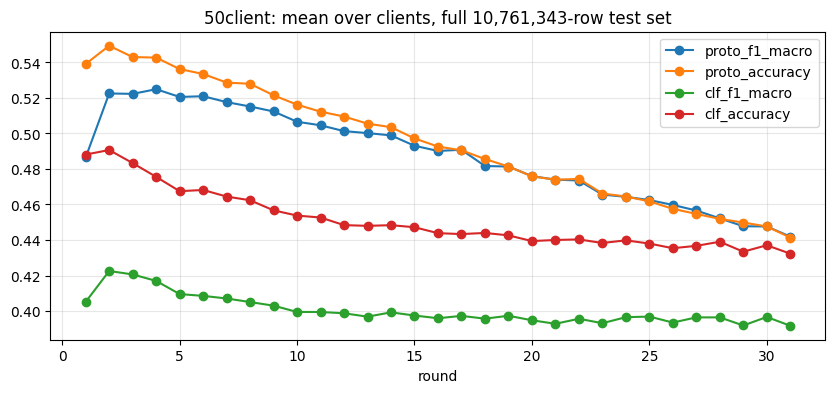

In [18]:
import pandas as pd
from proj.metrics import METRIC_KEYS, RULES
from proj import ckpt as C

OUT_ROOT = Path("/kaggle/working")
d = C.run_dir(OUT_ROOT, CFG["run_name"])
hp = d / "metrics" / "history.csv"
if not hp.exists():
    print("No completed rounds. Check logs/ for the stop reason.")
else:
    hist = pd.read_csv(hp).sort_values("round")
    assert not hist["round"].duplicated().any(), "duplicate round in history"
    print(f"Completed {C.last_complete(d)}/{CFG['rounds']} rounds")
    for rule in RULES:
        cols = ["round"] + [f"{rule}_{k}" for k in METRIC_KEYS]
        miss = set(cols) - set(hist.columns)
        assert not miss, f"incomplete metric schema for {rule}: {sorted(miss)}"
        v = hist[cols[1:]].to_numpy(float)
        assert np.isfinite(v).all() and ((v >= -1e-9) & (v <= 1 + 1e-9)).all()
        print(f"\n=== rule: {rule}  (mean over all {CFG['n_clients']} clients, full test set) ===")
        with pd.option_context("display.max_rows", None, "display.max_columns", None,
                               "display.width", 250):
            display(hist[cols].round(6))
    best = int(hist["round"].max())
    print(f"\nlast completed round (primary report): {best}")
    ax = hist.plot(x="round", y=["proto_f1_macro", "proto_accuracy",
                                 "clf_f1_macro", "clf_accuracy"],
                   marker="o", figsize=(10, 4))
    ax.set_title(f"{CFG['scenario']}: mean over clients, full {10_761_343:,}-row test set")
    ax.grid(alpha=.3)

    m = json.loads((d / "metrics" / f"round_{best:03d}.json").read_text())
    print(f"\n--- per-class, round {best}, rule=proto (pooled over clients) ---")
    display(pd.DataFrame(m["per_class"]["proto"]).round(4))
    print("\n--- spread across clients, round", best, "---")
    for rule in RULES:
        a = m["aggregate"][rule]
        print(f"  {rule:5s} f1_macro mean {a['mean_over_clients']['f1_macro']:.4f} "
              f"std {a['std_over_clients']['f1_macro']:.4f} "
              f"min {a['min_over_clients']['f1_macro']:.4f} "
              f"max {a['max_over_clients']['f1_macro']:.4f} | "
              f"pooled {a['pooled']['f1_macro']:.4f}")
    print(f"\ncommunication: {m['communication']['params_per_round']:,} params/round "
          f"({m['communication']['compression_vs_fedproto']:.2f}x below dense FedProto)")


## Reporting caveats — required beside every number above

1. **Not a reproduction of the paper.** Different dataset, task, class count, client
   architecture, α, round count and batch size. The method is inherited; the numbers are not
   comparable to Table 1 and must not be placed in the same table.
2. **`f1_macro`, not `accuracy`.** The test set is imbalanced 41:1 and two classes hold 44.5%
   of it. `precision_micro = recall_micro = f1_micro = recall_weighted = accuracy` is an
   identity of single-label multi-class classification, not a duplicated column.
3. **Personalized models.** There is no global model. Every number is a mean over the clients'
   own models on the same fixed global test set, which measures how well a personalized model
   generalizes globally — not how it performs on its own local distribution.
4. **One seed, one run.** No replication; the paper averages three seeds.
5. **μ came from a grid search on a train-side validation split**, not from the authors'
   (unpublished) selection method.
6. **Features are stored fp16** on the GPU. Measured max |x| = 570.44 against an fp16 ceiling of
   65504, so no saturation — but the stored value is genuinely quantized.
7. **`scaler.json` was fit on all 43 M training rows**, i.e. across every client. A real
   federated client has no such global statistic. This leak predates this build.
8. **Dataset caveats carry over**: simulation-time split, Sybil flow leakage, `benign` drawn
   from attack-free runs, 3,338,358 ambiguous rows dropped upstream, clients are receiver units
   rather than real vehicles, and the test set contains only the `_7` scenarios.
